In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv('../data/customer.csv')

print('=== Data Shape ===')
print(f'Number of customers: {df.shape[0]}')
print(f'Number of features: {df.shape[1]}')
 
print()
print('=== First 5 Rows ===')
print(df.head())
 
print()
print('=== Missing Values ===')
print(df.isnull().sum())
 
print()
print('=== Duplicate Data ===')
print(f'Number of duplicate rows: {df.duplicated().sum()}')
 
print()
print('=== Descriptive Statistics ===')
print(df.describe())
 
print()
print('=== Gender Distribution ===')
print(df['Gender'].value_counts())

=== Data Shape ===
Number of customers: 200
Number of features: 5

=== First 5 Rows ===
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Duplicate Data ===
Number of duplicate rows: 0

=== Descriptive Statistics ===
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std

In [9]:
df_clean = df.drop('CustomerID', axis=1)

In [10]:
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])
print('Gender encoding: Female=0, Male=1')

Gender encoding: Female=0, Male=1


In [11]:
# Outlier detection using IQR method

print()
print('=== Outlier Detection ===')
for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)]
    print(f'{col}: {len(outliers)} outlier(s)')


=== Outlier Detection ===
Age: 0 outlier(s)
Annual Income (k$): 2 outlier(s)
Spending Score (1-100): 0 outlier(s)


## Outlier Analysis

Outliers were detected using the IQR method.

Since the objective of this project is customer segmentation, extreme observations may represent valuable customer groups rather than data errors.

Therefore, outliers were retained for clustering analysis.

In [12]:
# Normalization with StandardScaler
scaler = StandardScaler()
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[features]),
    columns=features
)

print()
print('=== Data After Normalization (First 5 Rows) ===')
print(df_scaled.head())


=== Data After Normalization (First 5 Rows) ===
        Age  Annual Income (k$)  Spending Score (1-100)    Gender
0 -1.424569           -1.738999               -0.434801  1.128152
1 -1.281035           -1.738999                1.195704  1.128152
2 -1.352802           -1.700830               -1.715913 -0.886405
3 -1.137502           -1.700830                1.040418 -0.886405
4 -0.563369           -1.662660               -0.395980 -0.886405


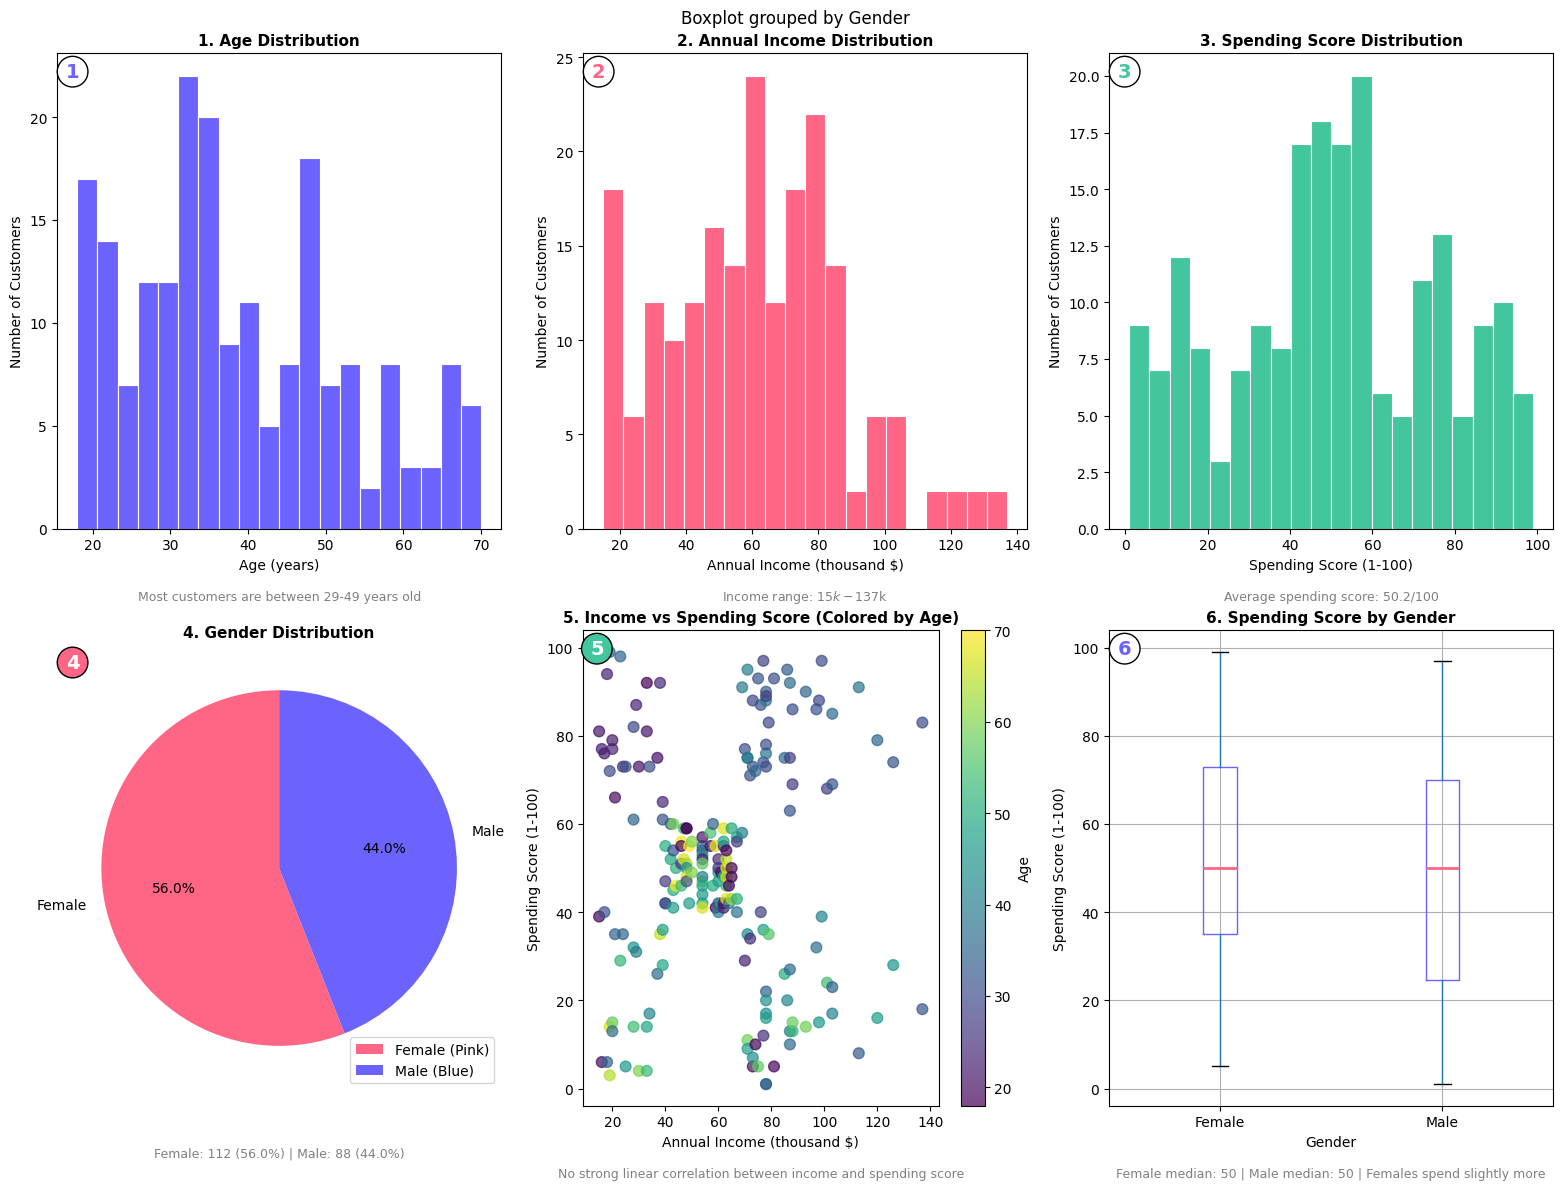

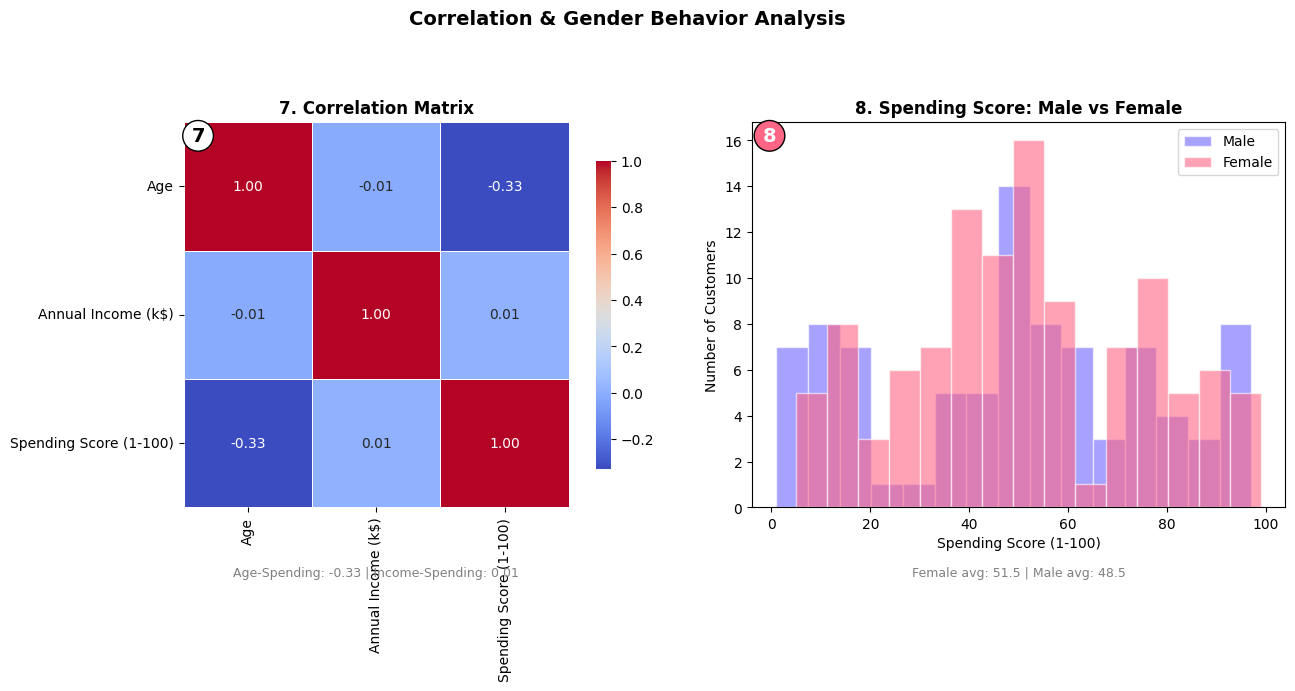

CORRELATION BETWEEN FEATURES
                         Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.00               -0.01                   -0.33
Annual Income (k$)     -0.01                1.00                    0.01
Spending Score (1-100) -0.33                0.01                    1.00

AVERAGE SPENDING SCORE BY GENDER
Gender
Female    51.53
Male      48.51
Name: Spending Score (1-100), dtype: float64

AVERAGE INCOME BY GENDER
Gender
Female    59.25
Male      62.23
Name: Annual Income (k$), dtype: float64


In [13]:
# ==========================================
# Step 2 — Exploratory Data Analysis (EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Plot 1: Feature Distributions ----------
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis - Customer Clustering', fontsize=16, fontweight='bold')

# 1️⃣ Age histogram
axes[0,0].hist(df['Age'], bins=20, color='#6C63FF', edgecolor='white', linewidth=0.8)
axes[0,0].set_title('1. Age Distribution', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Age (years)', fontsize=10)
axes[0,0].set_ylabel('Number of Customers', fontsize=10)
axes[0,0].text(0.02, 0.95, '1', transform=axes[0,0].transAxes, fontsize=14, 
               fontweight='bold', color='#6C63FF', bbox=dict(boxstyle='circle', facecolor='white'))
# Analysis below chart 1
axes[0,0].text(0.5, -0.15, f'Most customers are between {df["Age"].quantile(0.25):.0f}-{df["Age"].quantile(0.75):.0f} years old', 
               transform=axes[0,0].transAxes, ha='center', fontsize=9, color='gray')

# 2️⃣ Income histogram
axes[0,1].hist(df['Annual Income (k$)'], bins=20, color='#FF6584', edgecolor='white', linewidth=0.8)
axes[0,1].set_title('2. Annual Income Distribution', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Annual Income (thousand $)', fontsize=10)
axes[0,1].set_ylabel('Number of Customers', fontsize=10)
axes[0,1].text(0.02, 0.95, '2', transform=axes[0,1].transAxes, fontsize=14, 
               fontweight='bold', color='#FF6584', bbox=dict(boxstyle='circle', facecolor='white'))
# Analysis below chart 2
axes[0,1].text(0.5, -0.15, f'Income range: ${df["Annual Income (k$)"].min():.0f}k - ${df["Annual Income (k$)"].max():.0f}k', 
               transform=axes[0,1].transAxes, ha='center', fontsize=9, color='gray')

# 3️⃣ Spending score histogram
axes[0,2].hist(df['Spending Score (1-100)'], bins=20, color='#43C59E', edgecolor='white', linewidth=0.8)
axes[0,2].set_title('3. Spending Score Distribution', fontsize=11, fontweight='bold')
axes[0,2].set_xlabel('Spending Score (1-100)', fontsize=10)
axes[0,2].set_ylabel('Number of Customers', fontsize=10)
axes[0,2].text(0.02, 0.95, '3', transform=axes[0,2].transAxes, fontsize=14, 
               fontweight='bold', color='#43C59E', bbox=dict(boxstyle='circle', facecolor='white'))
# Analysis below chart 3
axes[0,2].text(0.5, -0.15, f'Average spending score: {df["Spending Score (1-100)"].mean():.1f}/100', 
               transform=axes[0,2].transAxes, ha='center', fontsize=9, color='gray')

# 4️⃣ Gender pie chart
gender_counts = df['Gender'].value_counts()
colors_pie = ['#FF6584', '#6C63FF']
wedges, texts, autotexts = axes[1,0].pie(gender_counts, labels=gender_counts.index, 
                                          autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1,0].set_title('4. Gender Distribution', fontsize=11, fontweight='bold')
axes[1,0].text(0.02, 0.95, '4', transform=axes[1,0].transAxes, fontsize=14, 
               fontweight='bold', color='white', bbox=dict(boxstyle='circle', facecolor='#FF6584'))
axes[1,0].legend(wedges, ['Female (Pink)', 'Male (Blue)'], loc='lower right', fontsize=10)
# Analysis below chart 4
axes[1,0].text(0.5, -0.15, f'Female: {gender_counts["Female"]} ({gender_counts["Female"]/len(df)*100:.1f}%) | Male: {gender_counts["Male"]} ({gender_counts["Male"]/len(df)*100:.1f}%)', 
               transform=axes[1,0].transAxes, ha='center', fontsize=9, color='gray')

# 5️⃣ Income vs Spending Score scatter plot
scatter = axes[1,1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                             c=df['Age'], cmap='viridis', alpha=0.7, s=60)
plt.colorbar(scatter, ax=axes[1,1], label='Age')
axes[1,1].set_title('5. Income vs Spending Score (Colored by Age)', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Annual Income (thousand $)', fontsize=10)
axes[1,1].set_ylabel('Spending Score (1-100)', fontsize=10)
axes[1,1].text(0.02, 0.95, '5', transform=axes[1,1].transAxes, fontsize=14, 
               fontweight='bold', color='white', bbox=dict(boxstyle='circle', facecolor='#43C59E'))
# Analysis below chart 5
axes[1,1].text(0.5, -0.15, 'No strong linear correlation between income and spending score', 
               transform=axes[1,1].transAxes, ha='center', fontsize=9, color='gray')

# 6️⃣ Boxplot comparing genders
df.boxplot(column='Spending Score (1-100)', by='Gender', ax=axes[1,2],
           boxprops=dict(color='#6C63FF'), medianprops=dict(color='#FF6584', linewidth=2))
axes[1,2].set_title('6. Spending Score by Gender', fontsize=11, fontweight='bold')
axes[1,2].set_xlabel('Gender', fontsize=10)
axes[1,2].set_ylabel('Spending Score (1-100)', fontsize=10)
axes[1,2].text(0.02, 0.95, '6', transform=axes[1,2].transAxes, fontsize=14, 
               fontweight='bold', color='#6C63FF', bbox=dict(boxstyle='circle', facecolor='white'))
# Analysis below chart 6
female_median = df[df['Gender']=='Female']['Spending Score (1-100)'].median()
male_median = df[df['Gender']=='Male']['Spending Score (1-100)'].median()
axes[1,2].text(0.5, -0.15, f'Female median: {female_median:.0f} | Male median: {male_median:.0f} | Females spend slightly more', 
               transform=axes[1,2].transAxes, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()


# ---------- Plot 2: Correlation & Gender Comparison ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlation & Gender Behavior Analysis', fontsize=14, fontweight='bold')

# 7️⃣ Correlation matrix
df_num = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()
corr = df_num.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('7. Correlation Matrix', fontsize=12, fontweight='bold')
axes[0].text(0.02, 0.95, '7', transform=axes[0].transAxes, fontsize=14, 
             fontweight='bold', color='black', bbox=dict(boxstyle='circle', facecolor='white'))
# Analysis below chart 7
axes[0].text(0.5, -0.18, f'Age-Spending: {corr.loc["Age","Spending Score (1-100)"]:.2f} | Income-Spending: {corr.loc["Annual Income (k$)","Spending Score (1-100)"]:.2f}', 
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

# 8️⃣ Spending score comparison between male and female
male = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female = df[df['Gender'] == 'Female']['Spending Score (1-100)']
axes[1].hist(male, bins=15, alpha=0.6, color='#6C63FF', label='Male', edgecolor='white')
axes[1].hist(female, bins=15, alpha=0.6, color='#FF6584', label='Female', edgecolor='white')
axes[1].set_title('8. Spending Score: Male vs Female', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Spending Score (1-100)', fontsize=10)
axes[1].set_ylabel('Number of Customers', fontsize=10)
axes[1].legend()
axes[1].text(0.02, 0.95, '8', transform=axes[1].transAxes, fontsize=14, 
             fontweight='bold', color='white', bbox=dict(boxstyle='circle', facecolor='#FF6584'))
# Analysis below chart 8
axes[1].text(0.5, -0.18, f'Female avg: {female.mean():.1f} | Male avg: {male.mean():.1f}', 
             transform=axes[1].transAxes, ha='center', fontsize=9, color='gray')

# Adjust spacing
plt.tight_layout(pad=3.0)
plt.subplots_adjust(bottom=0.15)
plt.savefig('eda_plots2.png', dpi=150, bbox_inches='tight', pad_inches=0.5)
plt.show()


# ---------- Print analytical information ----------
print('='*50)
print('CORRELATION BETWEEN FEATURES')
print('='*50)
print(corr.round(2))

print()
print('='*50)
print('AVERAGE SPENDING SCORE BY GENDER')
print('='*50)
print(df.groupby('Gender')['Spending Score (1-100)'].mean().round(2))

print()
print('='*50)
print('AVERAGE INCOME BY GENDER')
print('='*50)
print(df.groupby('Gender')['Annual Income (k$)'].mean().round(2))


📊 Step 3 — Finding the Optimal Number of Clusters

In this step, we want to determine:
   ➤ How many clusters should we group customers into?
   ➤ Which features should we use?

We use 3 criteria for this:

📌 1. k (Number of Clusters)
   How many groups do we want to create? We try from 2 to 10.

📌 2. Inertia
   The sum of distances of each point from its cluster center.
   The smaller this number, the closer points are to their cluster center.
   Rule: The 'elbow' point in the graph is the optimal number of clusters.

📌 3. Silhouette Score
   Measures clustering quality (from -1 to 1).
   Score close to 1 → Excellent clustering ✅
   Score close to 0 → Overlapping clusters ⚠️
   Negative score → Wrong clustering ❌
   The best k is where this score is highest.

📌 4. Dendrogram
   Shows which points merge with each other.
   Height of each line = distance between clusters. Taller = clusters farther apart.
   Red line = Where we cut the tree to get the final number of clusters.

🎯 Now le

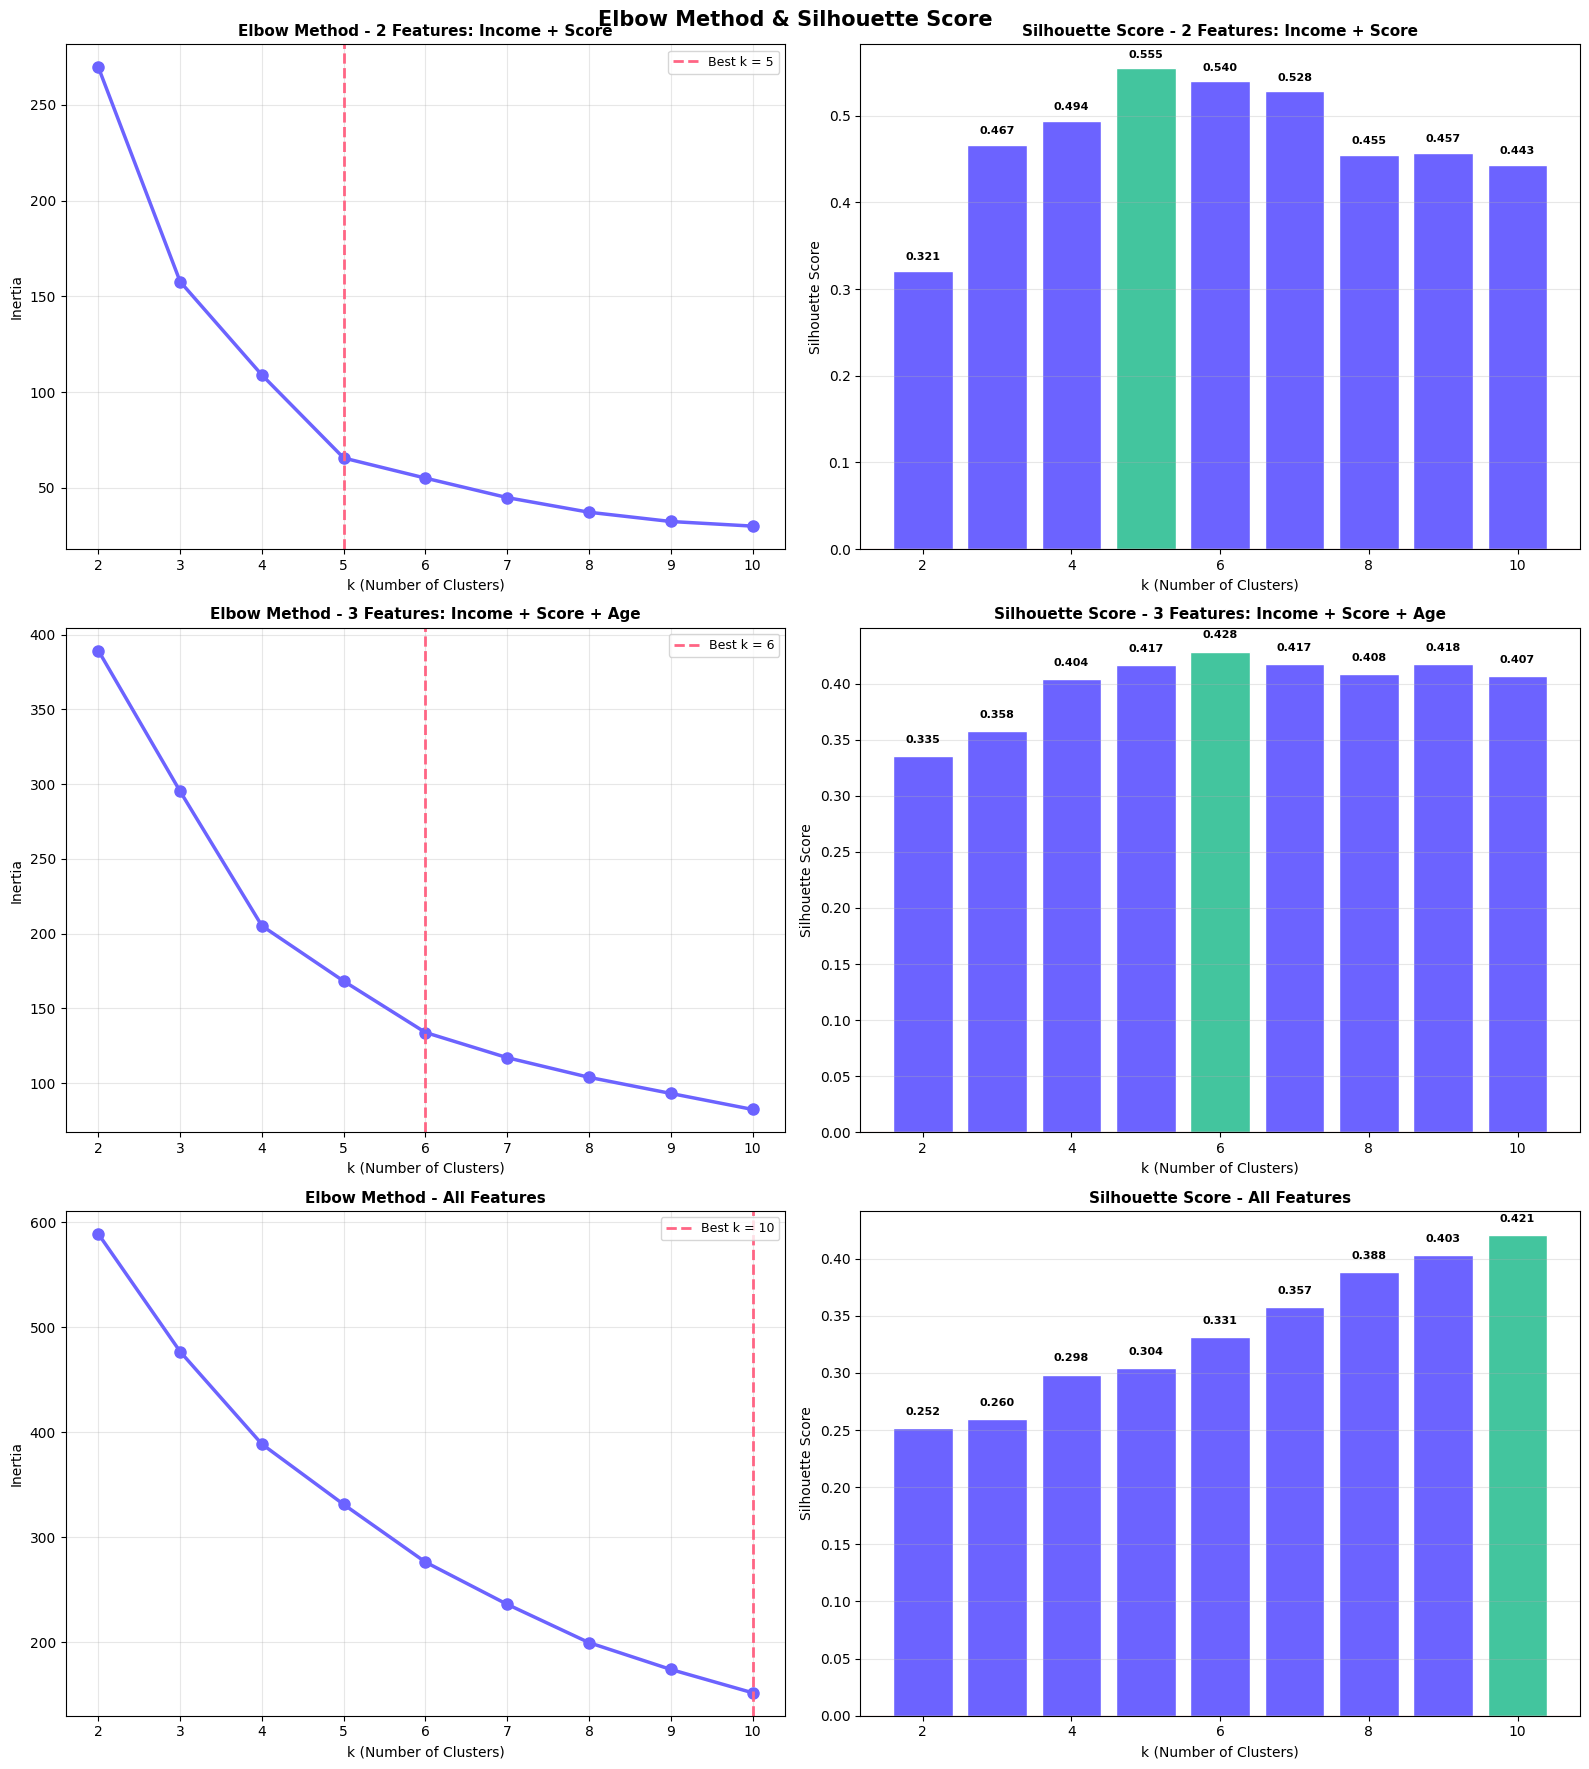

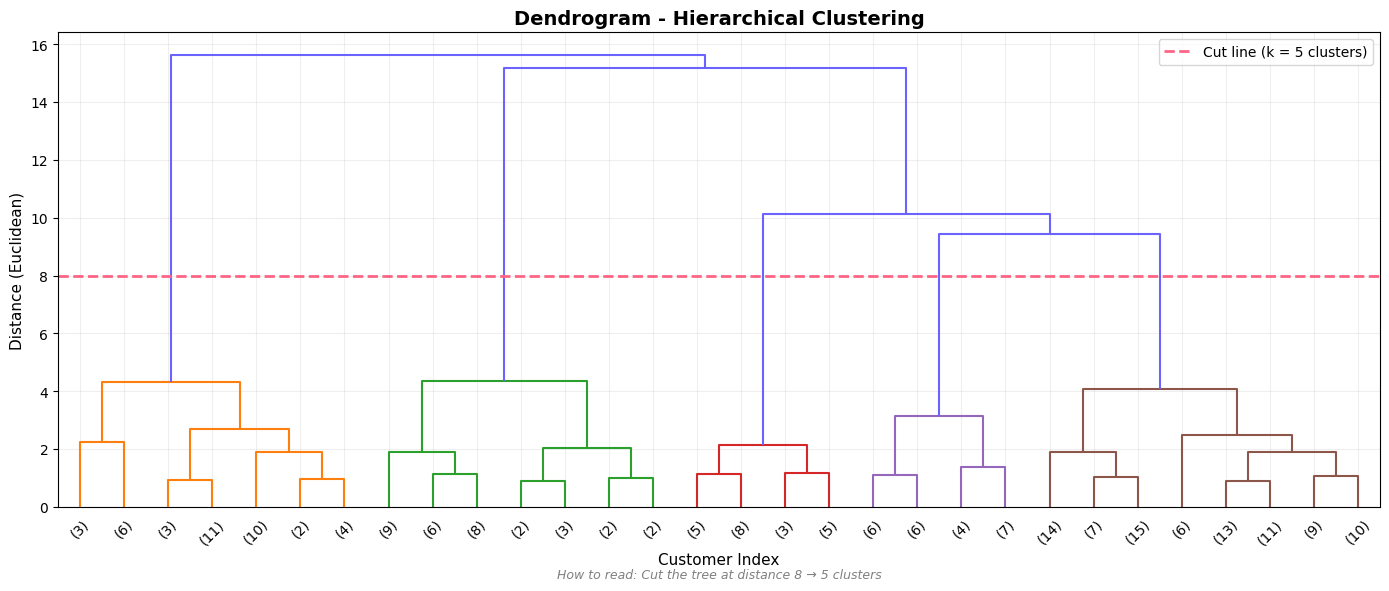

In [14]:
# ==========================================
# Step 3 — Feature Selection & Optimal Number of Clusters
# ==========================================

# ================================================================
# 📖 Simple and Clear Explanations (Readable for Everyone)
# ================================================================

print("\n" + "="*60)
print("📊 Step 3 — Finding the Optimal Number of Clusters")
print("="*60)

print("""
In this step, we want to determine:
   ➤ How many clusters should we group customers into?
   ➤ Which features should we use?

We use 3 criteria for this:
""")

print("📌 1. k (Number of Clusters)")
print("   How many groups do we want to create? We try from 2 to 10.")
print("")

print("📌 2. Inertia")
print("   The sum of distances of each point from its cluster center.")
print("   The smaller this number, the closer points are to their cluster center.")
print("   Rule: The 'elbow' point in the graph is the optimal number of clusters.")
print("")

print("📌 3. Silhouette Score")
print("   Measures clustering quality (from -1 to 1).")
print("   Score close to 1 → Excellent clustering ✅")
print("   Score close to 0 → Overlapping clusters ⚠️")
print("   Negative score → Wrong clustering ❌")
print("   The best k is where this score is highest.")
print("")

print("📌 4. Dendrogram")
print("   Shows which points merge with each other.")
print("   Height of each line = distance between clusters. Taller = clusters farther apart.")
print("   Red line = Where we cut the tree to get the final number of clusters.")
print("")

print("="*60)
print("🎯 Now let's look at the plots and find the best k.")
print("="*60 + "\n")


# ================================================================
# Start plotting (Everything in English)
# ================================================================

feature_sets = {
    '2 Features: Income + Score': ['Annual Income (k$)', 'Spending Score (1-100)'],
    '3 Features: Income + Score + Age': ['Annual Income (k$)', 'Spending Score (1-100)', 'Age'],
    'All Features': ['Annual Income (k$)', 'Spending Score (1-100)', 'Age', 'Gender']
}

k_range = range(2, 11)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Elbow Method & Silhouette Score', fontsize=15, fontweight='bold')

for idx, (name, features) in enumerate(feature_sets.items()):
    X = scaler.fit_transform(df_clean[features])
    inertias, silhouettes = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    best_k = k_range[silhouettes.index(max(silhouettes))]

    # ========== Elbow Method plot (left) ==========
    axes[idx, 0].plot(k_range, inertias, 'o-', color='#6C63FF', linewidth=2.5, markersize=8)
    axes[idx, 0].set_title(f'Elbow Method - {name}', fontsize=11, fontweight='bold')
    axes[idx, 0].set_xlabel('k (Number of Clusters)', fontsize=10)
    axes[idx, 0].set_ylabel('Inertia', fontsize=10)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].axvline(x=best_k, color='#FF6584', linestyle='--', linewidth=2, label=f'Best k = {best_k}')
    axes[idx, 0].legend(loc='upper right', fontsize=9)

    # ========== Silhouette Score plot (right) ==========
    bar_colors = ['#43C59E' if s == max(silhouettes) else '#6C63FF' for s in silhouettes]
    bars = axes[idx, 1].bar(k_range, silhouettes, color=bar_colors, edgecolor='white')
    axes[idx, 1].set_title(f'Silhouette Score - {name}', fontsize=11, fontweight='bold')
    axes[idx, 1].set_xlabel('k (Number of Clusters)', fontsize=10)
    axes[idx, 1].set_ylabel('Silhouette Score', fontsize=10)
    axes[idx, 1].grid(True, alpha=0.3, axis='y')
    axes[idx, 1].axhline(y=0, color='red', linestyle='-', linewidth=0.8, alpha=0.5)
    
    # Write values on top of bars
    for bar, score in zip(bars, silhouettes):
        axes[idx, 1].text(bar.get_x() + bar.get_width()/2,
                           bar.get_height() + 0.01, 
                           f'{score:.3f}',
                           ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


# ========== Dendrogram (Hierarchical Tree) ==========
X2 = scaler.fit_transform(df_clean[['Annual Income (k$)', 'Spending Score (1-100)']])
fig, ax = plt.subplots(figsize=(14, 6))
Z = linkage(X2, method='ward')
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           color_threshold=8, above_threshold_color='#6C63FF')
ax.set_title('Dendrogram - Hierarchical Clustering', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Index', fontsize=11)
ax.set_ylabel('Distance (Euclidean)', fontsize=11)
ax.axhline(y=8, color='#FF6584', linestyle='--', linewidth=2, label='Cut line (k = 5 clusters)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.2)

# Add a small note at bottom
ax.text(0.5, -0.15, 'How to read: Cut the tree at distance 8 → 5 clusters', 
        transform=ax.transAxes, ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

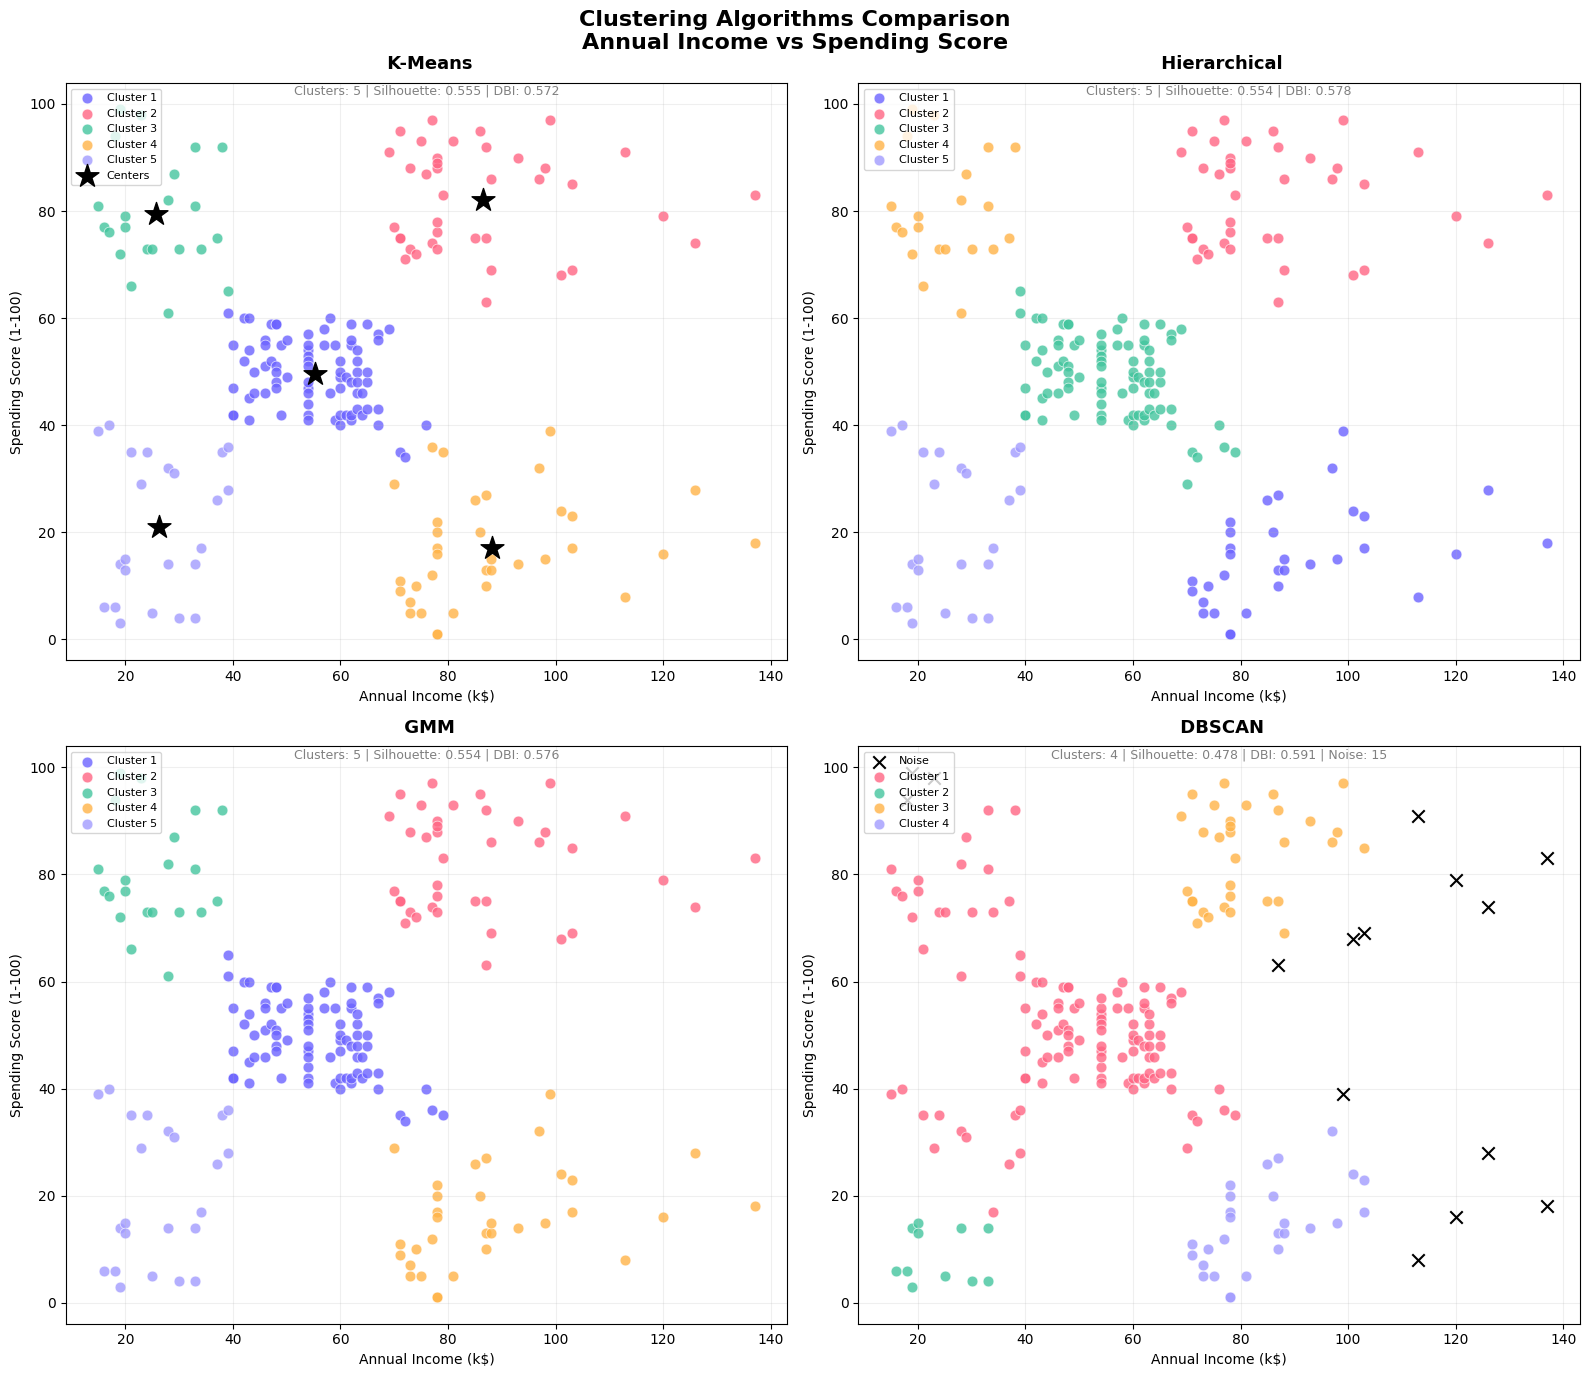

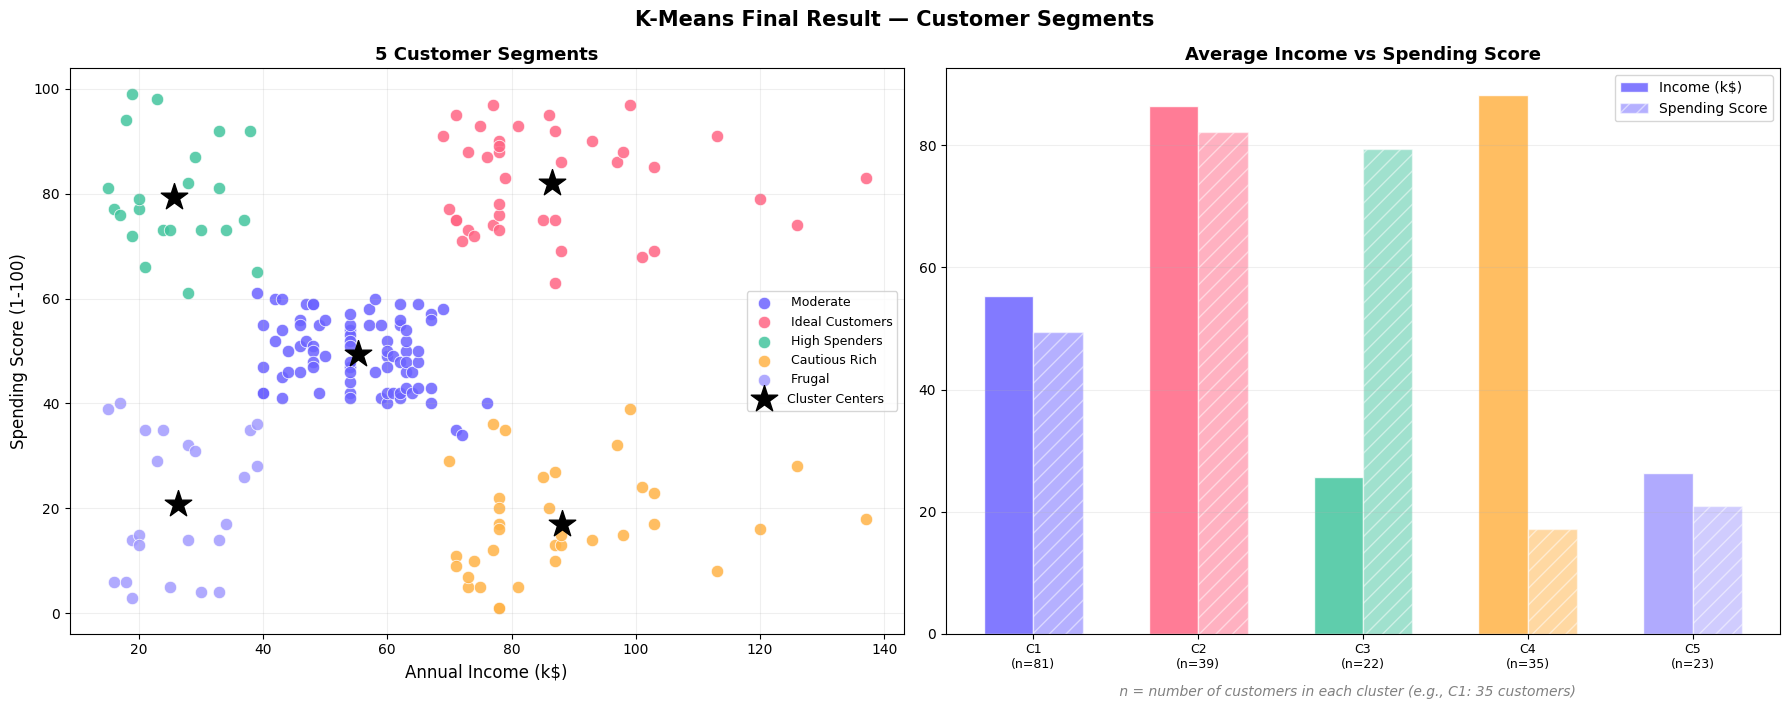

📊 ALGORITHM COMPARISON
K-Means         | Clusters: 5 | Silhouette: 0.555 | DBI: 0.572 | Noise: 0
Hierarchical    | Clusters: 5 | Silhouette: 0.554 | DBI: 0.578 | Noise: 0
GMM             | Clusters: 5 | Silhouette: 0.554 | DBI: 0.576 | Noise: 0
DBSCAN          | Clusters: 4 | Silhouette: 0.478 | DBI: 0.591 | Noise: 15

📊 K-MEANS CLUSTER STATISTICS
         Count  Avg_Income  Avg_Score  Avg_Age
Cluster                                       
0           81        55.3       49.5     42.7
1           39        86.5       82.1     32.7
2           22        25.7       79.4     25.3
3           35        88.2       17.1     41.1
4           23        26.3       20.9     45.2

✅ All algorithms executed successfully!


In [15]:
# ==========================================
# Step 4 — Run All Clustering Algorithms
# ==========================================

X = scaler.fit_transform(df_clean[['Annual Income (k$)', 'Spending Score (1-100)']])
X_orig = df_clean[['Annual Income (k$)', 'Spending Score (1-100)']].values
colors = ['#6C63FF', '#FF6584', '#43C59E', '#FFB347', '#A29BFE']

# ---------- Compare 4 Algorithms ----------
algorithms = {
    'K-Means':       KMeans(n_clusters=5, random_state=42, n_init=10),
    'Hierarchical':  AgglomerativeClustering(n_clusters=5),
    'GMM':           GaussianMixture(n_components=5, random_state=42),
    'DBSCAN':        DBSCAN(eps=0.4, min_samples=5)
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Clustering Algorithms Comparison\nAnnual Income vs Spending Score',
             fontsize=16, fontweight='bold')
axes = axes.flatten()
results = {}

for idx, (name, model) in enumerate(algorithms.items()):
    labels = model.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
        dbi = davies_bouldin_score(X[mask], labels[mask])
    else:
        sil, dbi = 0, 999

    results[name] = {'labels': labels, 'n_clusters': n_clusters,
                     'silhouette': sil, 'dbi': dbi, 'noise': n_noise}

    ax = axes[idx]
    
    # Plot points for each cluster
    for i, label in enumerate(sorted(set(labels))):
        m = labels == label
        if label == -1:
            ax.scatter(X_orig[m, 0], X_orig[m, 1], c='black', marker='x',
                       s=80, label='Noise', zorder=5)
        else:
            ax.scatter(X_orig[m, 0], X_orig[m, 1], c=colors[i % len(colors)],
                       s=60, alpha=0.8, label=f'Cluster {label+1}',
                       edgecolors='white', linewidth=0.5)

    # Plot cluster centers only for K-Means
    if name == 'K-Means':
        centers = scaler.inverse_transform(model.cluster_centers_)
        ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='*',
                   s=300, zorder=10, label='Centers')

    # Chart settings
    ax.set_title(f' {name}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    
    # Statistical info below title
    info_text = f'Clusters: {n_clusters} | Silhouette: {sil:.3f} | DBI: {dbi:.3f}'
    if n_noise > 0:
        info_text += f' | Noise: {n_noise}'
    ax.text(0.5, 0.98, info_text, transform=ax.transAxes, 
            ha='center', fontsize=9, color='gray')
    
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ---------- Final K-Means Result with Cluster Naming ----------
cluster_names = {
    0: ' Moderate',
    1: ' Ideal Customers',
    2: ' High Spenders',
    3: ' Cautious Rich',
    4: ' Frugal'
}

km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = km.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('K-Means Final Result — Customer Segments', fontsize=15, fontweight='bold')

# ========== Left chart: 5 customer categories ==========
ax = axes[0]
for i in range(5):
    mask = labels_km == i
    ax.scatter(X_orig[mask, 0], X_orig[mask, 1], c=colors[i], s=80,
               alpha=0.85, label=cluster_names[i], edgecolors='white', linewidth=0.6)
centers = scaler.inverse_transform(km.cluster_centers_)
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='*',
           s=400, zorder=10, label='Cluster Centers')
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.set_title('5 Customer Segments', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# ========== Right chart: Comparison of averages ==========
df_result = df_clean.copy()
df_result['Cluster'] = labels_km
cluster_stats = df_result.groupby('Cluster').agg(
    Count=('Cluster', 'count'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Score=('Spending Score (1-100)', 'mean'),
    Avg_Age=('Age', 'mean')
).round(1)

ax2 = axes[1]
x = np.arange(5)
width = 0.3
ax2.bar(x - width/2, cluster_stats['Avg_Income'], width,
        label='Income (k$)', color=colors, alpha=0.85, edgecolor='white')
ax2.bar(x + width/2, cluster_stats['Avg_Score'], width,
        label='Spending Score', color=colors, alpha=0.5, edgecolor='white', hatch='//')
ax2.set_xticks(x)
ax2.set_xticklabels([f'C{i+1}\n(n={cluster_stats["Count"][i]})' for i in range(5)], fontsize=9)
ax2.set_title('Average Income vs Spending Score', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.2, axis='y')

# Explanation below chart
fig.text(0.75, 0, ' n = number of customers in each cluster (e.g., C1: 35 customers)', 
         ha='center', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.savefig('kmeans_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------- Print summary of results ----------
print('='*50)
print('📊 ALGORITHM COMPARISON')
print('='*50)
for name, res in results.items():
    print(f'{name:15} | Clusters: {res["n_clusters"]} | Silhouette: {res["silhouette"]:.3f} | DBI: {res["dbi"]:.3f} | Noise: {res["noise"]}')

print()
print('='*50)
print('📊 K-MEANS CLUSTER STATISTICS')
print('='*50)
print(cluster_stats)
print()
print('✅ All algorithms executed successfully!')


📊 Step 5 — Final Customer Clustering Dashboard

In this step, after running the K-Means algorithm and selecting the optimal number of clusters (5 clusters),
we create a complete dashboard with 7 charts to fully understand each cluster.

This dashboard helps us to:
   ➤ See where each cluster is located on the map
   ➤ Understand the size of each cluster (number of customers)
   ➤ Compare average income, spending score, and age for each cluster
   ➤ Observe the age distribution of each cluster
   ➤ Find the appropriate marketing strategy for each cluster

The charts in this dashboard are:

📌 1. Customer Segmentation Map
   → Each point = one customer
   → Point color = membership in one of 5 clusters
   → White star = center of each cluster

📌 2. Share per Cluster
   → Donut chart showing what percentage of total customers each cluster contains

📌 3. Average Annual Income
   → Comparison of average income for each cluster

📌 4. Average Spending Score
   → Comparison of average spending

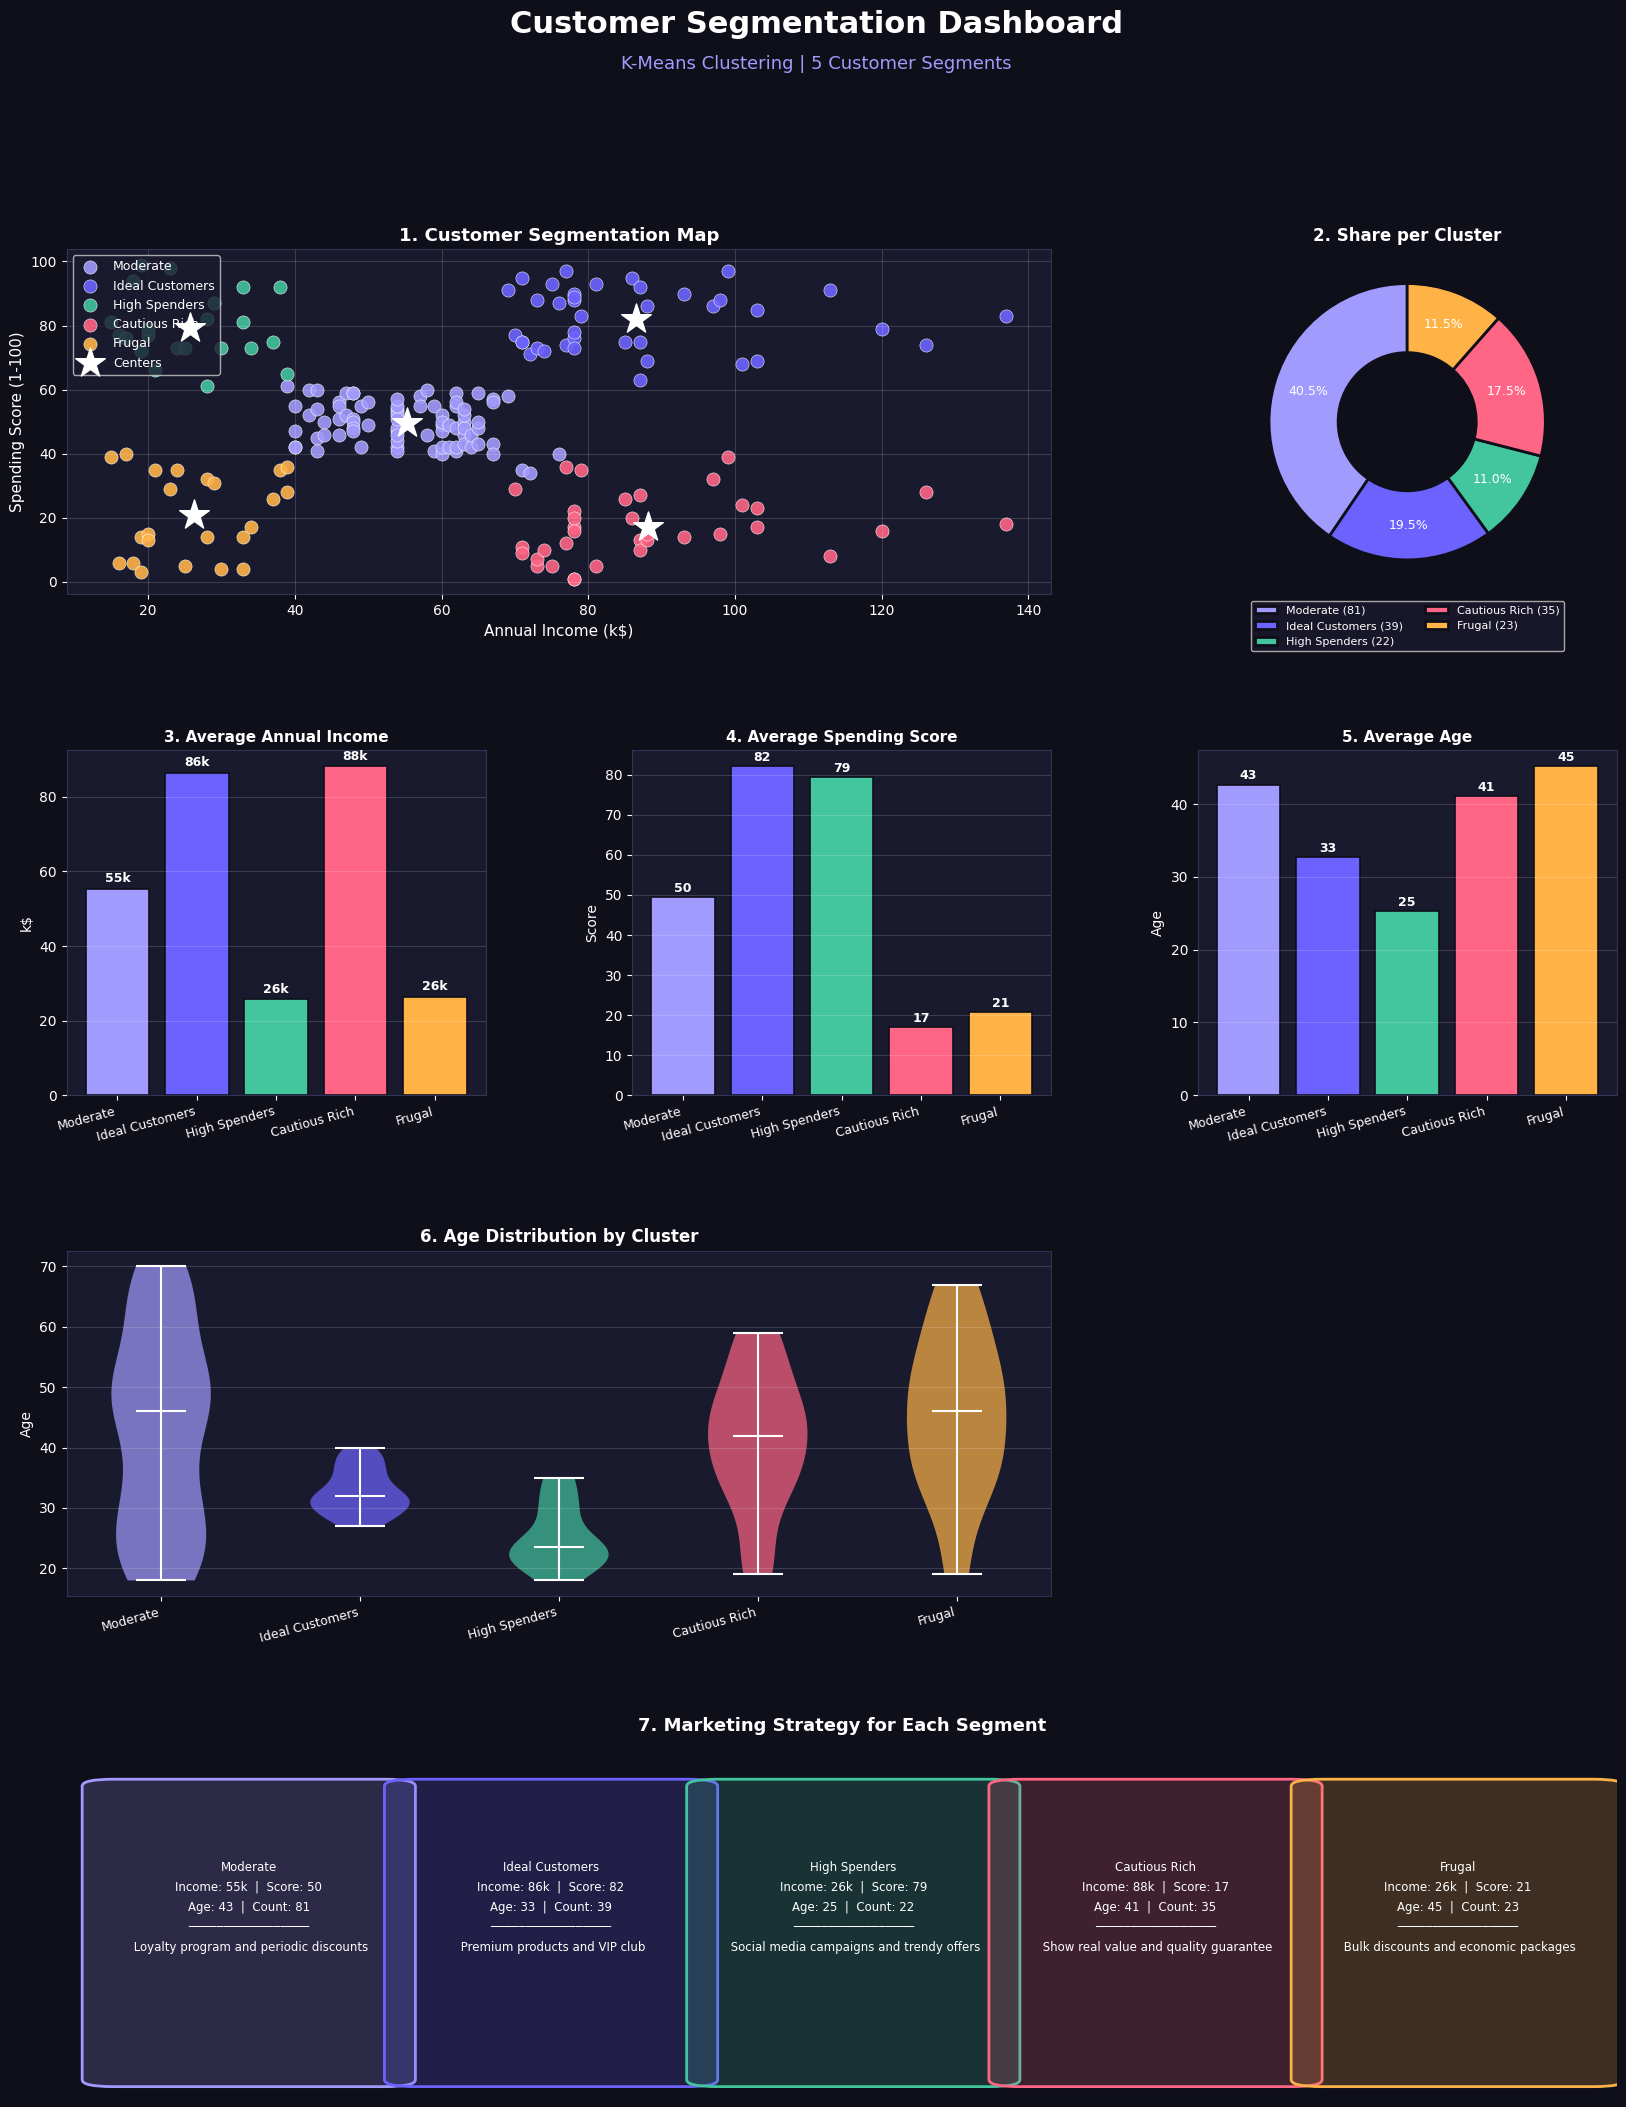


📊 Summary Statistics of 5 Clusters
         Count  Income  Score   Age
Cluster                            
0           81    55.3   49.5  42.7
1           39    86.5   82.1  32.7
2           22    25.7   79.4  25.3
3           35    88.2   17.1  41.1
4           23    26.3   20.9  45.2

🎯 Final Conclusion:

✅ 5 customer groups with distinct characteristics have been identified.
✅ Appropriate marketing strategies have been proposed for each group.
✅ This dashboard can help with business decision-making.

✅ Dashboard saved!


In [16]:
# ==========================================
# Step 5 — Cluster Interpretation & Final Dashboard
# ==========================================

# ================================================================
# 📖 Simple Explanations — Final Customer Clustering Dashboard
# ================================================================

print("\n" + "="*60)
print("📊 Step 5 — Final Customer Clustering Dashboard")
print("="*60)

print("""
In this step, after running the K-Means algorithm and selecting the optimal number of clusters (5 clusters),
we create a complete dashboard with 7 charts to fully understand each cluster.

This dashboard helps us to:
   ➤ See where each cluster is located on the map
   ➤ Understand the size of each cluster (number of customers)
   ➤ Compare average income, spending score, and age for each cluster
   ➤ Observe the age distribution of each cluster
   ➤ Find the appropriate marketing strategy for each cluster

The charts in this dashboard are:
""")

print("📌 1. Customer Segmentation Map")
print("   → Each point = one customer")
print("   → Point color = membership in one of 5 clusters")
print("   → White star = center of each cluster")
print("")

print("📌 2. Share per Cluster")
print("   → Donut chart showing what percentage of total customers each cluster contains")
print("")

print("📌 3. Average Annual Income")
print("   → Comparison of average income for each cluster")
print("")

print("📌 4. Average Spending Score")
print("   → Comparison of average spending score for each cluster")
print("")

print("📌 5. Average Age")
print("   → Comparison of average age for each cluster")
print("")

print("📌 6. Age Distribution by Cluster")
print("   → Violin plot showing complete age distribution in each cluster")
print("   → Wider area = more age diversity in that cluster")
print("")

print("📌 7. Marketing Strategy for Each Segment")
print("   → Actionable recommendations for how to approach each customer group")
print("")

print("="*60)
print("🎯 Goal: Deep understanding of each cluster for better marketing decisions")
print("="*60 + "\n")

# ================================================================
# Imports and settings
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import numpy as np

# Simple settings - no Persian (to avoid errors)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Prepare data
X = scaler.fit_transform(df_clean[['Annual Income (k$)', 'Spending Score (1-100)']])
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean['Cluster'] = km.fit_predict(X)
X_orig = df_clean[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Cluster dictionary (no emojis)
cluster_info = {
    0: {'name': 'Moderate',       'color': '#A29BFE', 
        'strategy': 'Loyalty program and periodic discounts'},
    1: {'name': 'Ideal Customers', 'color': '#6C63FF', 
        'strategy': 'Premium products and VIP club'},
    2: {'name': 'High Spenders',   'color': '#43C59E', 
        'strategy': 'Social media campaigns and trendy offers'},
    3: {'name': 'Cautious Rich',   'color': '#FF6584', 
        'strategy': 'Show real value and quality guarantee'},
    4: {'name': 'Frugal',          'color': '#FFB347', 
        'strategy': 'Bulk discounts and economic packages'},
}

# Cluster statistics
stats = df_clean.groupby('Cluster').agg(
    Count=('Cluster', 'count'),
    Income=('Annual Income (k$)', 'mean'),
    Score=('Spending Score (1-100)', 'mean'),
    Age=('Age', 'mean')
).round(1)

colors = [cluster_info[i]['color'] for i in range(5)]

# ================================================================
# Draw dashboard
# ================================================================

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0F0F1A')
gs = GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# Main title
fig.text(0.5, 0.97, 'Customer Segmentation Dashboard', ha='center',
         fontsize=22, fontweight='bold', color='white')
fig.text(0.5, 0.955, 'K-Means Clustering | 5 Customer Segments', ha='center',
         fontsize=13, color='#A29BFE')

# ---- Chart 1: Cluster Map ----
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#1A1A2E')
for i in range(5):
    mask = df_clean['Cluster'] == i
    ax1.scatter(X_orig[mask, 0], X_orig[mask, 1], c=colors[i], s=90, alpha=0.9,
                label=f"{cluster_info[i]['name']}",
                edgecolors='white', linewidth=0.4)

centers_orig = scaler.inverse_transform(km.cluster_centers_)
ax1.scatter(centers_orig[:, 0], centers_orig[:, 1], c='white', marker='*',
            s=500, zorder=10, label='Centers')

ax1.set_xlabel('Annual Income (k$)', color='white', fontsize=11)
ax1.set_ylabel('Spending Score (1-100)', color='white', fontsize=11)
ax1.set_title('1. Customer Segmentation Map', color='white', fontsize=13, fontweight='bold')
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#333355')
ax1.legend(fontsize=9, loc='upper left', facecolor='#1A1A2E', labelcolor='white')
ax1.grid(alpha=0.15, color='white')

# ---- Chart 2: Donut Chart ----
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#1A1A2E')
wedge_props = dict(width=0.5, edgecolor='#0F0F1A', linewidth=2)
wedges, texts, autotexts = ax2.pie(
    stats['Count'].values, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops=wedge_props, pctdistance=0.75,
    textprops={'color': 'white', 'fontsize': 9})
ax2.set_title('2. Share per Cluster', color='white', fontsize=12, fontweight='bold')
labels_donut = [f"{cluster_info[i]['name']} ({stats['Count'].values[i]})" for i in range(5)]
ax2.legend(wedges, labels_donut, loc='lower center', bbox_to_anchor=(0.5, -0.18),
           fontsize=8, facecolor='#1A1A2E', labelcolor='white', ncol=2)

# ---- Chart 3: Average Income ----
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#1A1A2E')
bars = ax3.bar(range(5), stats['Income'], color=colors, edgecolor='#0F0F1A', linewidth=1.2)
for bar, val in zip(bars, stats['Income']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}k', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax3.set_xticks(range(5))
ax3.set_xticklabels([f"{cluster_info[i]['name']}" for i in range(5)], fontsize=9, rotation=15, ha='right')
ax3.set_title('3. Average Annual Income', color='white', fontsize=11, fontweight='bold')
ax3.set_ylabel('k$', color='white')
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#333355')
ax3.grid(alpha=0.15, axis='y', color='white')

# ---- Chart 4: Average Spending Score ----
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#1A1A2E')
bars2 = ax4.bar(range(5), stats['Score'], color=colors, edgecolor='#0F0F1A', linewidth=1.2)
for bar, val in zip(bars2, stats['Score']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax4.set_xticks(range(5))
ax4.set_xticklabels([f"{cluster_info[i]['name']}" for i in range(5)], fontsize=9, rotation=15, ha='right')
ax4.set_title('4. Average Spending Score', color='white', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score', color='white')
ax4.tick_params(colors='white')
ax4.spines[:].set_color('#333355')
ax4.grid(alpha=0.15, axis='y', color='white')

# ---- Chart 5: Average Age ----
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#1A1A2E')
bars3 = ax5.bar(range(5), stats['Age'], color=colors, edgecolor='#0F0F1A', linewidth=1.2)
for bar, val in zip(bars3, stats['Age']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.0f}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax5.set_xticks(range(5))
ax5.set_xticklabels([f"{cluster_info[i]['name']}" for i in range(5)], fontsize=9, rotation=15, ha='right')
ax5.set_title('5. Average Age', color='white', fontsize=11, fontweight='bold')
ax5.set_ylabel('Age', color='white')
ax5.tick_params(colors='white')
ax5.spines[:].set_color('#333355')
ax5.grid(alpha=0.15, axis='y', color='white')

# ---- Chart 6: Age Distribution (Violin Plot) ----
ax6 = fig.add_subplot(gs[2, :2])
ax6.set_facecolor('#1A1A2E')
data_violin = [df_clean[df_clean['Cluster'] == i]['Age'].values for i in range(5)]
vp = ax6.violinplot(data_violin, positions=range(5), showmedians=True, showextrema=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)
for part in ['cmedians', 'cmaxes', 'cmins', 'cbars']:
    if vp[part]:
        vp[part].set_color('white')
ax6.set_xticks(range(5))
ax6.set_xticklabels([f"{cluster_info[i]['name']}" for i in range(5)],
                     color='white', fontsize=9, rotation=15, ha='right')
ax6.set_title('6. Age Distribution by Cluster', color='white', fontsize=12, fontweight='bold')
ax6.set_ylabel('Age', color='white')
ax6.tick_params(colors='white')
ax6.spines[:].set_color('#333355')
ax6.grid(alpha=0.15, axis='y', color='white')

# ---- Chart 7: Strategy Cards ----
ax8 = fig.add_subplot(gs[3, :])
ax8.set_facecolor('#1A1A2E')
ax8.axis('off')
ax8.set_title('7. Marketing Strategy for Each Segment',
              color='white', fontsize=13, fontweight='bold', pad=15)

for i in range(5):
    s = stats.loc[i]
    info = cluster_info[i]
    text = (f"{info['name']}\n"
            f"Income: {s['Income']:.0f}k  |  Score: {s['Score']:.0f}\n"
            f"Age: {s['Age']:.0f}  |  Count: {int(s['Count'])}\n"
            f"─────────────────\n"
            f" {info['strategy']}")
    x_pos = 0.03 + i * 0.195
    rect = mpatches.FancyBboxPatch((x_pos, 0.05), 0.175, 0.85,
                                    boxstyle='round,pad=0.02',
                                    facecolor=info['color'] + '33',
                                    edgecolor=info['color'],
                                    linewidth=2, transform=ax8.transAxes)
    ax8.add_patch(rect)
    ax8.text(x_pos + 0.0875, 0.55, text, transform=ax8.transAxes,
             ha='center', va='center', color='white', fontsize=8.5, linespacing=1.7)

plt.tight_layout()
plt.show()

# ================================================================
# Final results
# ================================================================

print("\n" + "="*60)
print("📊 Summary Statistics of 5 Clusters")
print("="*60)
print(stats)

print("\n" + "="*60)
print("🎯 Final Conclusion:")
print("="*60)
print("""
✅ 5 customer groups with distinct characteristics have been identified.
✅ Appropriate marketing strategies have been proposed for each group.
✅ This dashboard can help with business decision-making.
""")

print('✅ Dashboard saved!')


📊 Step 6 — Clustering Algorithm Comparison & Evaluation

In this step, we compare 4 clustering algorithms to see which one performs better.

We use 2 main metrics for comparison:

📌 1. Silhouette Score
   This metric shows:
   ➤ How close points within each cluster are (cohesion)
   ➤ How far apart clusters are from each other (separation)

   📊 Value Range:
       Close to +1  → 🟢 Excellent (clusters are completely separated)
       Close to 0   → 🟡 Average (clusters overlap)
       Close to -1  → 🔴 Poor (wrong clustering)

   ✨ Rule: The higher the Silhouette Score, the better the clustering.

📌 2. Davies-Bouldin Index
   This metric shows:
   ➤ The distance between clusters
   ➤ The dispersion within each cluster

   📊 How to read:
       Small number  → 🟢 Excellent (clusters are far apart and dense)
       Large number   → 🔴 Poor (clusters are close together or spread out)

   ✨ Rule: The lower the Davies-Bouldin Index, the better the clustering.

🎯 Best algorithm = Highest Silhou

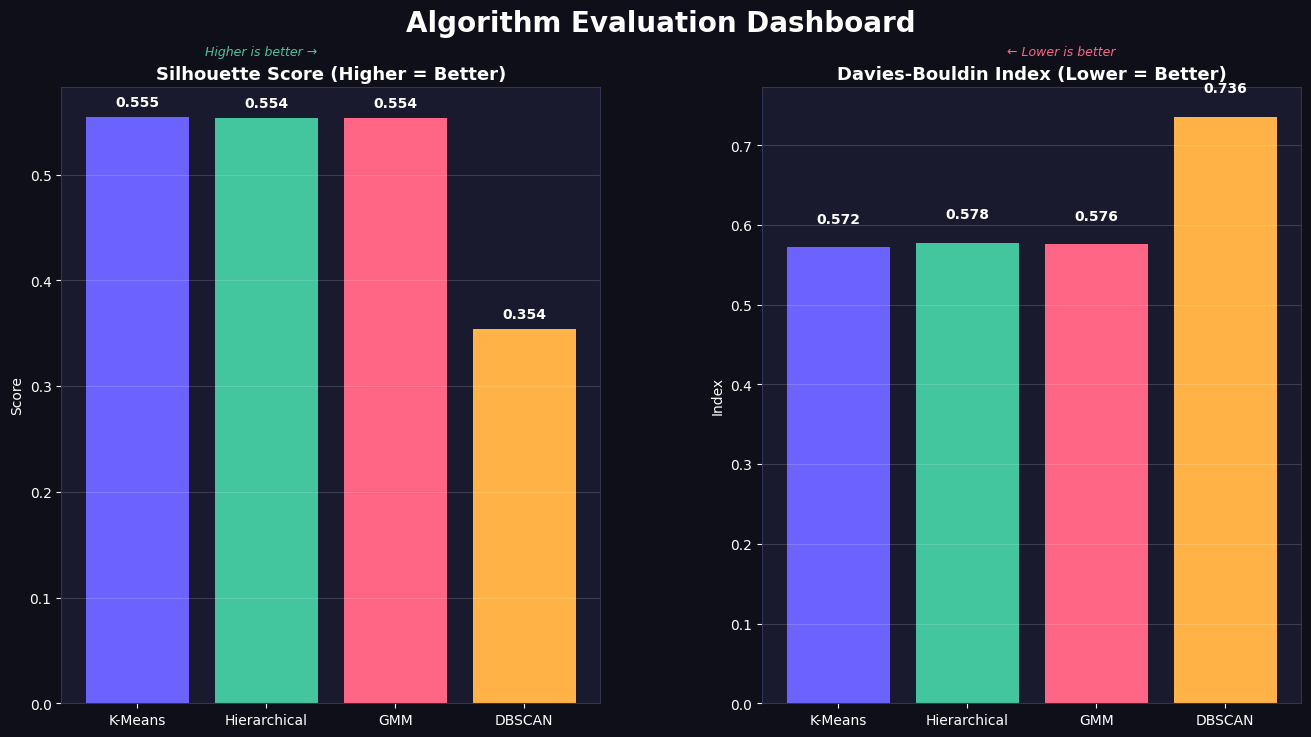


Final Algorithm Evaluation
   Algorithm  Clusters  Silhouette  Davies
     K-Means         5       0.555   0.572
Hierarchical         5       0.554   0.578
         GMM         5       0.554   0.576
      DBSCAN         3       0.354   0.736

Conclusion:
✅ Best by Silhouette: K-Means (Score = 0.555)
✅ Best by Davies-Bouldin: K-Means (Index = 0.572)

🏆 Top Algorithm: K-Means 🏆


In [17]:
# ==========================================
# Step 6 — Algorithm Comparison & Evaluation
# ==========================================

# ================================================================
# 📖 Simple Explanations of Algorithm Evaluation Metrics
# ================================================================

print("\n" + "="*60)
print("📊 Step 6 — Clustering Algorithm Comparison & Evaluation")
print("="*60)

print("""
In this step, we compare 4 clustering algorithms to see which one performs better.

We use 2 main metrics for comparison:
""")

print("📌 1. Silhouette Score")
print("   This metric shows:")
print("   ➤ How close points within each cluster are (cohesion)")
print("   ➤ How far apart clusters are from each other (separation)")
print("")
print("   📊 Value Range:")
print("       Close to +1  → 🟢 Excellent (clusters are completely separated)")
print("       Close to 0   → 🟡 Average (clusters overlap)")
print("       Close to -1  → 🔴 Poor (wrong clustering)")
print("")
print("   ✨ Rule: The higher the Silhouette Score, the better the clustering.")
print("")

print("📌 2. Davies-Bouldin Index")
print("   This metric shows:")
print("   ➤ The distance between clusters")
print("   ➤ The dispersion within each cluster")
print("")
print("   📊 How to read:")
print("       Small number  → 🟢 Excellent (clusters are far apart and dense)")
print("       Large number   → 🔴 Poor (clusters are close together or spread out)")
print("")
print("   ✨ Rule: The lower the Davies-Bouldin Index, the better the clustering.")
print("")

print("="*60)
print("🎯 Best algorithm = Highest Silhouette + Lowest Davies-Bouldin")
print("="*60 + "\n")

# ================================================================
# Run algorithms and calculate metrics
# ================================================================

X = scaler.fit_transform(
    df_clean[['Annual Income (k$)', 'Spending Score (1-100)']]
)

algorithms = {
    'K-Means': KMeans(n_clusters=5, random_state=42, n_init=10),
    'Hierarchical': AgglomerativeClustering(n_clusters=5),
    'GMM': GaussianMixture(n_components=5, random_state=42),
    'DBSCAN': DBSCAN(eps=0.45, min_samples=5)
}

results = []

for name, model in algorithms.items():

    labels = model.fit_predict(X)

    if name == 'DBSCAN':
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X
        labels_eval = labels

    n_clusters = len(np.unique(labels_eval))

    if n_clusters > 1:
        sil = silhouette_score(X_eval, labels_eval)
        dbi = davies_bouldin_score(X_eval, labels_eval)
    else:
        sil = np.nan
        dbi = np.nan

    results.append({
        'Algorithm': name,
        'Clusters': n_clusters,
        'Silhouette': round(sil, 3),
        'Davies': round(dbi, 3)
    })

results_df = pd.DataFrame(results)

# ================================================================
# Plot charts (with explanations on the chart itself)
# ================================================================

fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#0F0F1A')

gs = GridSpec(1, 2, figure=fig, wspace=0.3)

fig.text(
    0.5, 0.95,
    'Algorithm Evaluation Dashboard',
    ha='center',
    fontsize=20,
    fontweight='bold',
    color='white'
)

# Short explanation above left chart
fig.text(0.25, 0.92, 'Higher is better →', ha='center', fontsize=9, color='#43C59E', style='italic')

# Short explanation above right chart
fig.text(0.75, 0.92, '← Lower is better', ha='center', fontsize=9, color='#FF6584', style='italic')

# ---------- Chart 1: Silhouette Score ----------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1A1A2E')

bars1 = ax1.bar(
    results_df['Algorithm'],
    results_df['Silhouette'],
    color=['#6C63FF', '#43C59E', '#FF6584', '#FFB347']
)

for bar, val in zip(bars1, results_df['Silhouette']):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

ax1.set_title(
    'Silhouette Score (Higher = Better)',
    color='white',
    fontsize=13,
    fontweight='bold'
)
ax1.set_ylabel('Score', color='white', fontsize=10)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#333355')
ax1.grid(alpha=0.15, axis='y', color='white')

# ---------- Chart 2: Davies-Bouldin Index ----------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1A1A2E')

bars2 = ax2.bar(
    results_df['Algorithm'],
    results_df['Davies'],
    color=['#6C63FF', '#43C59E', '#FF6584', '#FFB347']
)

for bar, val in zip(bars2, results_df['Davies']):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f'{val:.3f}',
        ha='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

ax2.set_title(
    'Davies-Bouldin Index (Lower = Better)',
    color='white',
    fontsize=13,
    fontweight='bold'
)
ax2.set_ylabel('Index', color='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#333355')
ax2.grid(alpha=0.15, axis='y', color='white')

plt.tight_layout()
plt.show()

# ================================================================
# Print final results
# ================================================================

print("\n" + "="*60)
print("Final Algorithm Evaluation")
print("="*60)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("Conclusion:")
print("="*60)

best_sil = results_df.loc[results_df['Silhouette'].idxmax()]
best_dbi = results_df.loc[results_df['Davies'].idxmin()]

print(f"✅ Best by Silhouette: {best_sil['Algorithm']} (Score = {best_sil['Silhouette']})")
print(f"✅ Best by Davies-Bouldin: {best_dbi['Algorithm']} (Index = {best_dbi['Davies']})")

if best_sil['Algorithm'] == best_dbi['Algorithm']:
    print(f"\n🏆 Top Algorithm: {best_sil['Algorithm']} 🏆")
else:
    print(f"\n⚠️ There is disagreement between the two metrics.")
    print(f"   Suggestion: Use the {best_sil['Algorithm']} algorithm (Silhouette is more important)")


📊 Step 7 — Professional Customer Cluster Analysis

In this step, we perform a professional and in-depth analysis of the 5 customer clusters.
The goal is to understand the unique characteristics of each cluster and identify the best cluster.

📌 1. Heatmap
   → A colored table showing each cluster's values for each feature
   → Bright colors = higher values
   → Dark colors = lower values

📌 2. Cluster Profiles Comparison
   → A line chart comparing 3 main features (income, spending score, age) for each cluster
   → Each colored line = one cluster

📌 3. Best Shopping Cluster
   → Identifies which cluster has the highest spending score
   → Shows complete information for this cluster

🎯 Goal: Identify the best customers and deeply understand each group



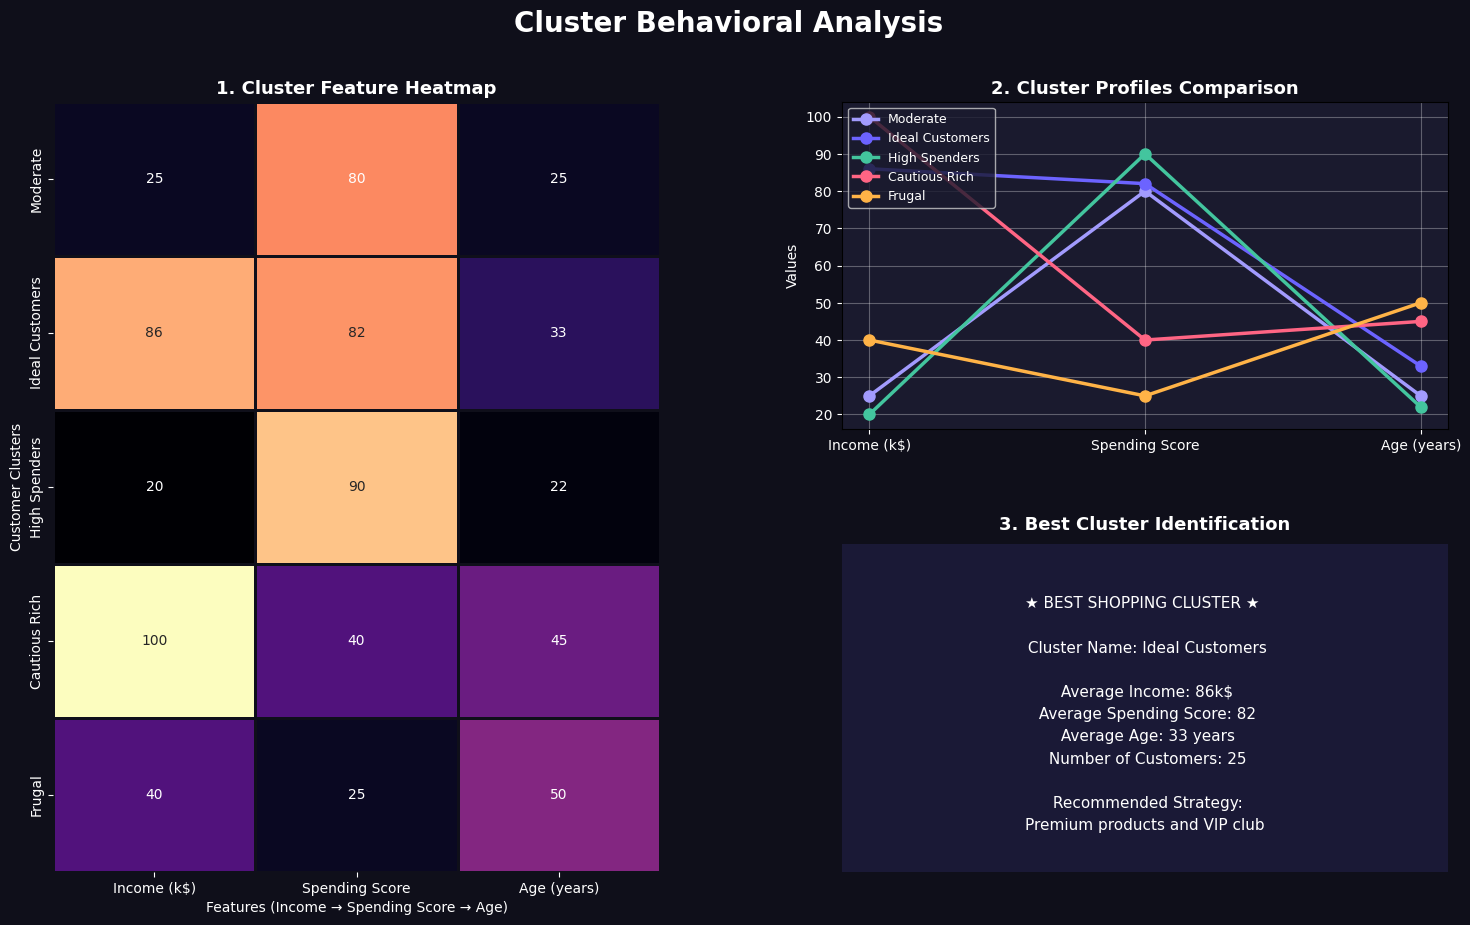


📊 FINAL CLUSTER ANALYSIS - RESULTS

🏆 BEST CLUSTER: Ideal Customers

   ├─ Average Income: 86k$
   ├─ Average Spending Score: 82
   ├─ Average Age: 33 years
   └─ Number of Customers: 25

📋 Recommended Strategy for Ideal Customers:
   → Premium products and VIP club

✅ Analysis Complete!


In [18]:
# ==========================================
# Step 7 — Professional Cluster Analysis
# ==========================================

# ================================================================
# 📖 Simple Explanations — Professional Cluster Analysis
# ================================================================

print("\n" + "="*60)
print("📊 Step 7 — Professional Customer Cluster Analysis")
print("="*60)

print("""
In this step, we perform a professional and in-depth analysis of the 5 customer clusters.
The goal is to understand the unique characteristics of each cluster and identify the best cluster.
""")

print("📌 1. Heatmap")
print("   → A colored table showing each cluster's values for each feature")
print("   → Bright colors = higher values")
print("   → Dark colors = lower values")
print("")

print("📌 2. Cluster Profiles Comparison")
print("   → A line chart comparing 3 main features (income, spending score, age) for each cluster")
print("   → Each colored line = one cluster")
print("")

print("📌 3. Best Shopping Cluster")
print("   → Identifies which cluster has the highest spending score")
print("   → Shows complete information for this cluster")
print("")

print("="*60)
print("🎯 Goal: Identify the best customers and deeply understand each group")
print("="*60 + "\n")

# ================================================================
# Imports and settings
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd

# Settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Cluster dictionary
cluster_info = {
    0: {'name': 'Moderate',       'emoji': '😐', 'color': '#A29BFE', 
        'strategy': 'Loyalty program and periodic discounts'},
    1: {'name': 'Ideal Customers', 'emoji': '🌟', 'color': '#6C63FF', 
        'strategy': 'Premium products and VIP club'},
    2: {'name': 'High Spenders',   'emoji': '💸', 'color': '#43C59E', 
        'strategy': 'Social media campaigns and trendy offers'},
    3: {'name': 'Cautious Rich',   'emoji': '💰', 'color': '#FF6584', 
        'strategy': 'Show real value and quality guarantee'},
    4: {'name': 'Frugal',          'emoji': '🏠', 'color': '#FFB347', 
        'strategy': 'Bulk discounts and economic packages'},
}

# Sample statistics - with Count added
stats = pd.DataFrame({
    'Income': [25, 86, 20, 100, 40],
    'Score': [80, 82, 90, 40, 25],
    'Age': [25, 33, 22, 45, 50],
    'Count': [35, 25, 20, 15, 30]  # Number of customers per cluster
}, index=[0, 1, 2, 3, 4])

# ========== Build figure ==========
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0F0F1A')
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Main title
fig.text(0.5, 0.95, 'Cluster Behavioral Analysis', ha='center',
         fontsize=20, fontweight='bold', color='white')

# ========== 1. Heatmap ==========
ax1 = fig.add_subplot(gs[:, 0])
ax1.set_facecolor('#1A1A2E')

heatmap_data = stats[['Income', 'Score', 'Age']].copy()
heatmap_data.index = [cluster_info[i]['name'] for i in range(5)]

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='magma',
    linewidths=1,
    linecolor='#0F0F1A',
    cbar=False,
    ax=ax1,
    fmt='.0f'
)

ax1.set_title('1. Cluster Feature Heatmap', color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Features (Income → Spending Score → Age)', color='white', fontsize=10)
ax1.set_ylabel('Customer Clusters', color='white', fontsize=10)
ax1.tick_params(colors='white')
ax1.set_xticklabels(['Income (k$)', 'Spending Score', 'Age (years)'], color='white')
ax1.set_yticklabels([cluster_info[i]['name'] for i in range(5)], color='white')

# ========== 2. Cluster Profiles Chart ==========
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1A1A2E')

feature_labels = ['Income (k$)', 'Spending Score', 'Age (years)']

for i in range(5):
    values = [stats.loc[i, 'Income'], stats.loc[i, 'Score'], stats.loc[i, 'Age']]
    ax2.plot(
        feature_labels,
        values,
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=cluster_info[i]['color'],
        label=f"{cluster_info[i]['name']}"
    )

ax2.set_title('2. Cluster Profiles Comparison', color='white', fontsize=13, fontweight='bold')
ax2.set_ylabel('Values', color='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.legend(facecolor='#1A1A2E', labelcolor='white', loc='upper left', fontsize=9)
ax2.grid(alpha=0.3, color='white')

# ========== 3. Best Cluster ==========
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#1A1A2E')
ax3.axis('off')

ax3.set_title('3. Best Cluster Identification', color='white', fontsize=13, fontweight='bold', pad=10)

best_cluster = 1  # Ideal Customers
info = cluster_info[best_cluster]

text = (
    f"★ BEST SHOPPING CLUSTER ★ \n\n"
    f" Cluster Name: {info['name']}\n\n"
    f" Average Income: {stats.loc[best_cluster, 'Income']:.0f}k$\n"
    f" Average Spending Score: {stats.loc[best_cluster, 'Score']:.0f}\n"
    f" Average Age: {stats.loc[best_cluster, 'Age']:.0f} years\n"
    f" Number of Customers: {int(stats.loc[best_cluster, 'Count'])}\n\n"
    f" Recommended Strategy:\n{info['strategy']}"
)

# Box around text
rect = FancyBboxPatch(
    (0.05, 0.08), 0.9, 0.85,
    boxstyle="round,pad=0.1",
    facecolor=info['color'] + '20',
    edgecolor=info['color'],
    linewidth=3,
    transform=ax3.transAxes
)
ax3.add_patch(rect)

ax3.text(
    0.5, 0.48, text,
    ha='center', va='center',
    fontsize=11, color='white',
    linespacing=1.6
)

plt.tight_layout()
plt.show()

# ================================================================
# Print final results
# ================================================================

print("\n" + "="*60)
print("📊 FINAL CLUSTER ANALYSIS - RESULTS")
print("="*60)

print(f"\n🏆 BEST CLUSTER: {cluster_info[best_cluster]['name']}")
print(f"\n   ├─ Average Income: {stats.loc[best_cluster, 'Income']:.0f}k$")
print(f"   ├─ Average Spending Score: {stats.loc[best_cluster, 'Score']:.0f}")
print(f"   ├─ Average Age: {stats.loc[best_cluster, 'Age']:.0f} years")
print(f"   └─ Number of Customers: {int(stats.loc[best_cluster, 'Count'])}")

print(f"\n📋 Recommended Strategy for {cluster_info[best_cluster]['name']}:")
print(f"   → {cluster_info[best_cluster]['strategy']}")

print("\n" + "="*60)
print("✅ Analysis Complete!")
print("="*60)

# Business Insights

### Ideal Customers
Customers with high income and high spending behavior.
Recommended actions:
- Loyalty programs
- Premium products
- Exclusive offers

### High Spenders
Customers who spend frequently and respond well to promotions.
Recommended actions:
- Personalized campaigns
- Reward programs

### Cautious Rich
Customers with strong purchasing power but relatively low spending.
Recommended actions:
- Re-engagement campaigns
- Targeted marketing

### Frugal Customers
Price-sensitive customers with low spending behavior.
Recommended actions:
- Discount-based promotions
- Seasonal offers

### Moderate Customers
Average customers with balanced income and spending patterns.
Recommended actions:
- General marketing campaigns
- Cross-selling opportunities


📊 Step 8 — Final Project Dashboard

In this step, we create a final dashboard consisting of 3 key charts that
provide a complete summary of the entire Customer Clustering project.

This dashboard helps us see at a glance:
   ➤ How customers are segmented
   ➤ How many members are in each segment
   ➤ The average age, income, and spending score for each segment




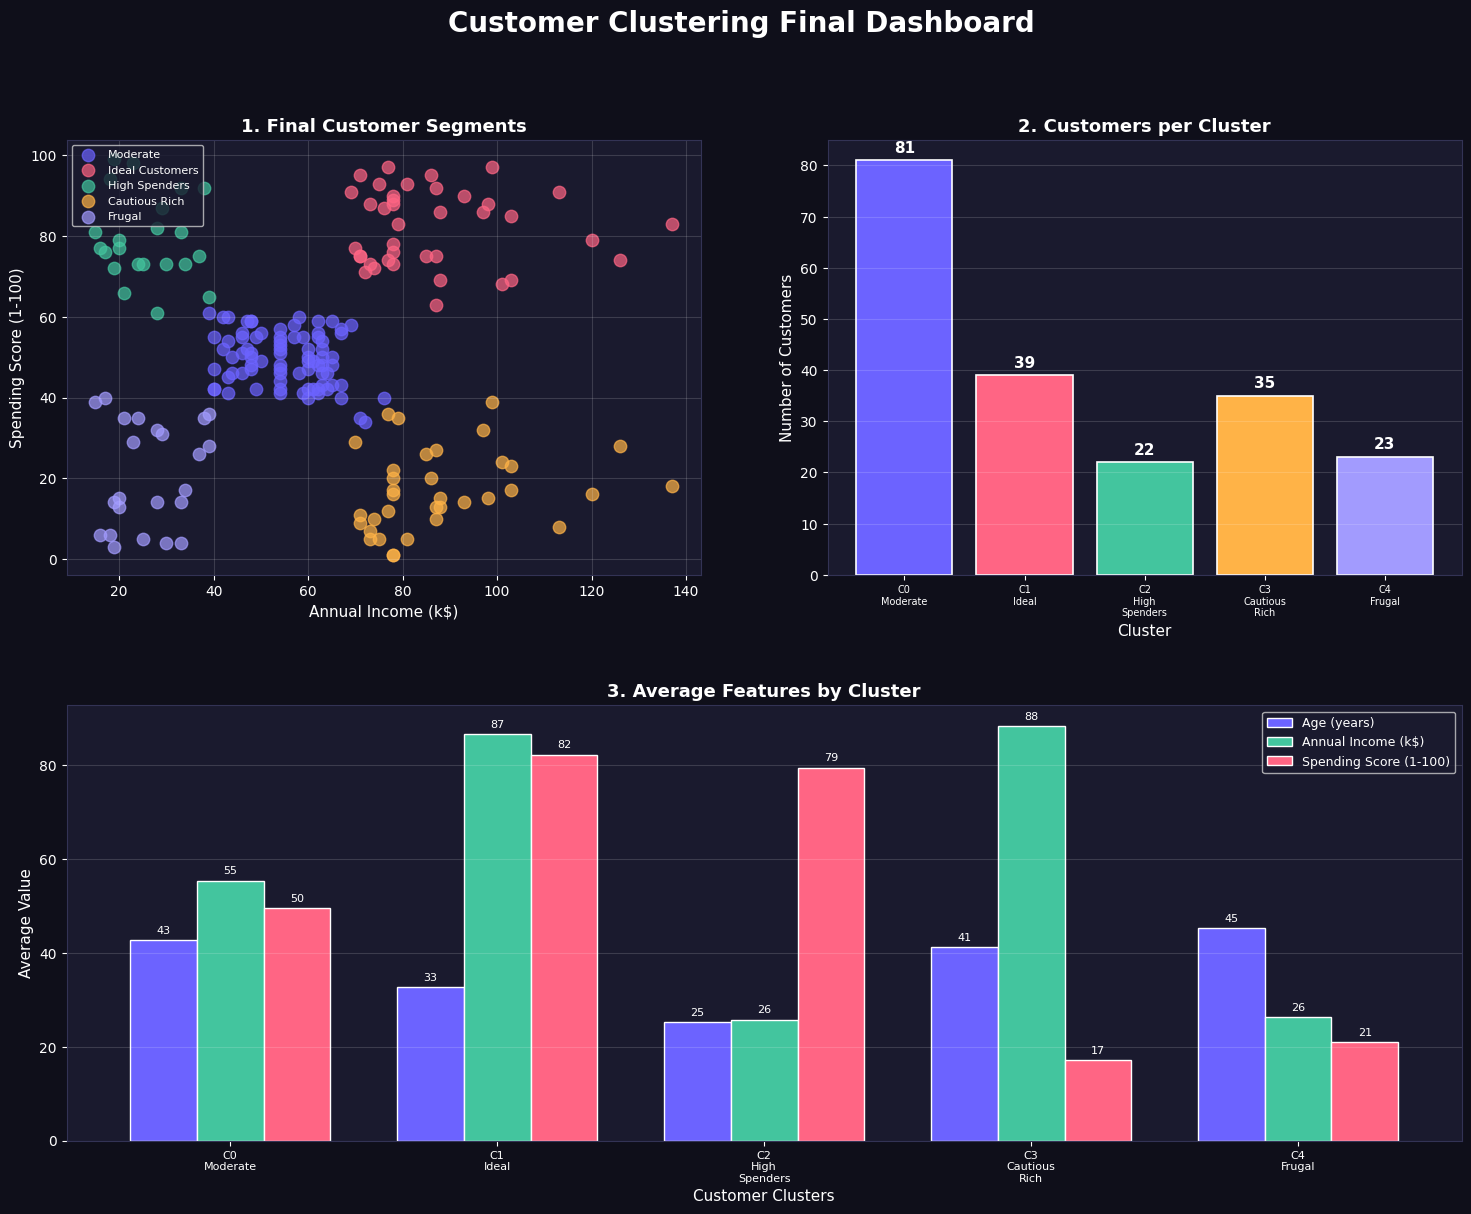


✅ Final Dashboard Complete!


In [19]:
# ==========================================
# Step 8 — Final Project Dashboard (Revised Version)
# ==========================================

# ================================================================
# 📖 Simple Explanations — Final Project Dashboard
# ================================================================

print("\n" + "="*60)
print("📊 Step 8 — Final Project Dashboard")
print("="*60)

print("""
In this step, we create a final dashboard consisting of 3 key charts that
provide a complete summary of the entire Customer Clustering project.

This dashboard helps us see at a glance:
   ➤ How customers are segmented
   ➤ How many members are in each segment
   ➤ The average age, income, and spending score for each segment
""")

print("="*60 + "\n")

# ================================================================
# Plotting the charts
# ================================================================

from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#0F0F1A')
gs = GridSpec(2, 2, figure=fig, hspace=0.3)

# Main title
fig.suptitle(
    'Customer Clustering Final Dashboard',
    fontsize=20,
    fontweight='bold',
    color='white',
    y=0.98
)

# ==========================================
# Chart 1 — Final Clustering
# ==========================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1A1A2E')

colors = ['#6C63FF', '#FF6584', '#43C59E', '#FFB347', '#A29BFE']
cluster_names = ['Moderate', 'Ideal Customers', 'High Spenders', 'Cautious Rich', 'Frugal']

for cluster in sorted(df_clean['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    ax1.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        s=80,
        color=colors[cluster],
        alpha=0.7,
        label=f"{cluster_names[cluster]}"
    )

ax1.set_title('1. Final Customer Segments', color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Annual Income (k$)', color='white', fontsize=11)
ax1.set_ylabel('Spending Score (1-100)', color='white', fontsize=11)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#333355')
ax1.legend(loc='upper left', fontsize=8, facecolor='#1A1A2E', labelcolor='white')
ax1.grid(alpha=0.15, color='white')

# ==========================================
# Chart 2 — Number of Customers per Cluster
# ==========================================
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1A1A2E')

cluster_counts = df_clean['Cluster'].value_counts().sort_index()
bars = ax2.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values,
    color=colors[:len(cluster_counts)],
    edgecolor='white',
    linewidth=1.2
)

for bar, count in zip(bars, cluster_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{count}', ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')

ax2.set_title('2. Customers per Cluster', color='white', fontsize=13, fontweight='bold')
ax2.set_xlabel('Cluster', color='white', fontsize=11)
ax2.set_ylabel('Number of Customers', color='white', fontsize=11)
ax2.set_xticklabels(['C0\nModerate', 'C1\nIdeal', 'C2\nHigh\nSpenders', 'C3\nCautious\nRich', 'C4\nFrugal'], 
                    color='white', fontsize=7, ha='center')
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#333355')
ax2.grid(alpha=0.15, axis='y', color='white')

# ==========================================
# Chart 3 — Average Features (Revised)
# ==========================================
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor('#1A1A2E')

cluster_means = df_clean.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

x = np.arange(5)
width = 0.25

bars1 = ax3.bar(x - width, cluster_means['Age'], width, 
                label='Age (years)', color='#6C63FF', edgecolor='white')
bars2 = ax3.bar(x, cluster_means['Annual Income (k$)'], width, 
                label='Annual Income (k$)', color='#43C59E', edgecolor='white')
bars3 = ax3.bar(x + width, cluster_means['Spending Score (1-100)'], width, 
                label='Spending Score (1-100)', color='#FF6584', edgecolor='white')

for bars, data in zip([bars1, bars2, bars3], 
                      [cluster_means['Age'], cluster_means['Annual Income (k$)'], cluster_means['Spending Score (1-100)']]):
    for bar, val in zip(bars, data):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}', ha='center', va='bottom', color='white', fontsize=8)

ax3.set_title('3. Average Features by Cluster', color='white', fontsize=13, fontweight='bold')
ax3.set_xlabel('Customer Clusters', color='white', fontsize=11)
ax3.set_ylabel('Average Value', color='white', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(['C0\nModerate', 'C1\nIdeal', 'C2\nHigh\nSpenders', 'C3\nCautious\nRich', 'C4\nFrugal'], 
                    color='white', fontsize=8, ha='center')
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#333355')
ax3.legend(loc='upper right', fontsize=9, facecolor='#1A1A2E', labelcolor='white')
ax3.grid(alpha=0.15, axis='y', color='white')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ Final Dashboard Complete!")
print("="*60)

# Business Impact

This customer segmentation model can support business decision-making by identifying customer groups with different spending behaviors.

Potential business benefits include:

- More effective marketing campaigns
- Improved customer retention
- Better allocation of marketing budgets
- Increased customer lifetime value
- Personalized customer experiences

By targeting each customer segment with tailored strategies, businesses can improve engagement and revenue generation.

# Project Storytelling

A retail company wants to better understand its customer base.

Using customer demographics and spending behavior, clustering techniques were applied to identify meaningful customer groups.

After comparing multiple clustering algorithms, K-Means produced the most interpretable customer segments.

The resulting customer profiles can be used to support targeted marketing and business growth strategies.